<h1 style="color:rgb(242, 176, 235); font-size:32px;">Import modules</h1>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Loading datasets</h1>

In [14]:
directory = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing/app/data/cleaned_data/extranat/competitions_per_type")

data = []

for file in directory.rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data.append(json.load(f))

rows = []
for comp in data:
    for epreuve in comp.get("epreuves", []):
        for perf in epreuve.get("performances", []):

            swimmers = perf.get("swimmer", [])
            if isinstance(swimmers, dict):
                swimmers = [swimmers]

            row = {
                "Meet": comp.get("Meet"),
                "SwimDate": comp.get("SwimDate"),
                "Location": comp.get("location"),
                "Country": comp.get("Country"),
                "Event": epreuve.get("Event"),
                "Distance": epreuve.get("Distance"),
                "Stroke": epreuve.get("Stroke"),
                "Course": epreuve.get("Course"),
                "PoolLength": epreuve.get("PoolLength"),
                "Tour": epreuve.get("tour"),
                "Rank": perf.get("Rank"),
                "Club": perf.get("club"),
                "points": perf.get("points"),
                "mpp": perf.get("mpp"),
                "mpp_date": perf.get("mpp_date"),
                "SwimTime": perf.get("SwimTime"),
                "SwimYear": perf.get("SwimYear"),
                "SwimTimeSeconds": perf.get("SwimTimeSeconds"),
                "Status": perf.get("Status"),
                "Speed": perf.get("Speed"),
                "swimmer": swimmers, 
                "splits": perf.get("splits", [])
            }

            rows.append(row)

df = pd.DataFrame(rows)

print(df.head())
print("Nombre de SwimTime :", df['SwimTime'].notna().sum())

                                            Meet    SwimDate   Location  \
0  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
1  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
2  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
3  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
4  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   

  Country       Event  Distance Stroke Course  PoolLength    Tour  ...  \
0     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
1     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
2     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
3     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
4     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   

   points       mpp    mpp_date  SwimTime SwimYear SwimTimeSeconds Status  \
0   930.0  02:08.48  2025-1

In [12]:
import pandas as pd
import unicodedata

# =========================
# 1. Préparation des données
# =========================

df_check = df.explode("swimmer").copy()
df_check = df_check[df_check["swimmer"].apply(lambda x: isinstance(x, dict))]

df_check["Nageur"] = df_check["swimmer"].apply(lambda x: x.get("Name"))
df_check["Sexe"] = df_check["swimmer"].apply(lambda x: x.get("Gender"))
df_check["Annee"] = df_check["swimmer"].apply(lambda x: x.get("Year_of_birth"))

# =========================
# 2. Fonctions de nettoyage
# =========================

def normalize_text(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    x = " ".join(x.split())
    x = unicodedata.normalize("NFC", x)
    return x

def normalize_sex(x):
    if pd.isna(x):
        return pd.NA
    return str(x).strip().upper()

# =========================
# 3. Nettoyage des colonnes
# =========================

df_check["Nageur_clean"] = df_check["Nageur"].map(normalize_text)
df_check["Sexe_clean"] = df_check["Sexe"].map(normalize_sex)
df_check["Annee_clean"] = pd.to_numeric(df_check["Annee"], errors="coerce").astype("Int64")

CURRENT_YEAR = pd.Timestamp.today().year

# =========================
# 4. Détection des anomalies
# =========================

issues = {
    "annee_manquante": df_check[df_check["Annee_clean"].isna()],
    
    "annee_hors_plage": df_check[
        df_check["Annee_clean"].notna() &
        ((df_check["Annee_clean"] < 1900) | (df_check["Annee_clean"] > CURRENT_YEAR))
    ],
    
    "nageur_manquant": df_check[
        df_check["Nageur_clean"].isna() | (df_check["Nageur_clean"] == "")
    ],
    
    "sexe_invalide": df_check[
        ~df_check["Sexe_clean"].isin(["M", "F"]) &
        df_check["Sexe_clean"].notna()
    ],
    
    "sexe_manquant": df_check[df_check["Sexe_clean"].isna()],
}

# =========================
# 5. Pourcentage Year_of_birth non valides
# =========================
# Non valides = manquants OU hors plage [1900, CURRENT_YEAR]

invalid_yob_mask = (
    df_check["Annee_clean"].isna() |
    (df_check["Annee_clean"] < 1900) |
    (df_check["Annee_clean"] > CURRENT_YEAR)
)

nb_invalid_yob = invalid_yob_mask.sum()
pct_invalid_yob = invalid_yob_mask.mean() * 100

print(f"Year_of_birth non valides : {nb_invalid_yob} / {len(df_check)} ({pct_invalid_yob:.2f}%)")

# =========================
# 6. Résumé global
# =========================

print("===== Résumé qualité =====")
for k, v in issues.items():
    print(f"{k:20s}: {len(v)}")

# =========================
# 7. Cohérence nageurs
# =========================

consistency = (
    df_check.dropna(subset=["Nageur_clean"])
    .groupby("Nageur_clean", as_index=False)
    .agg(
        nb_sexes=("Sexe_clean", "nunique"),
        nb_annees=("Annee_clean", "nunique")
    )
)

incoherent = consistency[
    (consistency["nb_sexes"] > 1) |
    (consistency["nb_annees"] > 1)
]

print(f"\nNageurs incohérents: {len(incoherent)}")

# =========================
# 8. MEETS AVEC ANNEES HORS PLAGE
# =========================

print("\n===== MEETS AVEC ANNEES HORS PLAGE =====")

meets_invalid = issues["annee_hors_plage"]["Meet"].dropna().unique()
print(meets_invalid)

# =========================
# 9. NOMBRE D'OCCURRENCES PAR MEET
# =========================

print("\n===== NOMBRE D'OCCURRENCES PAR MEET =====")

display(
    issues["annee_hors_plage"]["Meet"]
    .value_counts()
    .head(20)
)

# =========================
# 10. EXEMPLES DETAILLES
# =========================

print("\n===== EXEMPLES =====")

display(
    issues["annee_hors_plage"][
        ["Meet", "Nageur", "Annee", "Sexe"]
    ].head(20)
)

# =========================
# 11. TAUX D'ERREUR PAR MEET
# =========================

ratio_invalid = (
    df_check.groupby("Meet")["Annee_clean"]
    .apply(lambda x: ((x < 1900) | (x > CURRENT_YEAR)).mean())
    .sort_values(ascending=False)
)

print("\n===== TOP MEETS LES PLUS PROBLEMATIQUES =====")
display(ratio_invalid.head(20))

# =========================
# 12. DEBUG D'UN MEET
# =========================

if len(meets_invalid) > 0:
    meet_name = meets_invalid[0]
    
    print(f"\n===== DEBUG MEET : {meet_name} =====")
    
    display(
        df_check[df_check["Meet"] == meet_name][
            ["Meet", "Nageur", "Annee", "Sexe"]
        ].head(30)
    )

Year_of_birth non valides : 4 / 895808 (0.00%)
===== Résumé qualité =====
annee_manquante     : 0
annee_hors_plage    : 4
nageur_manquant     : 0
sexe_invalide       : 0
sexe_manquant       : 0

Nageurs incohérents: 314

===== MEETS AVEC ANNEES HORS PLAGE =====
["Championnats d'Europe en petit bassin"]

===== NOMBRE D'OCCURRENCES PAR MEET =====


Meet
Championnats d'Europe en petit bassin    4
Name: count, dtype: int64


===== EXEMPLES =====


,Meet,Nageur,Annee,Sexe
73249,Championnats d'Europe en petit bassin,Paut Karlo-Noah,4200,M
73322,Championnats d'Europe en petit bassin,Paut Karlo-Noah,4200,M
73896,Championnats d'Europe en petit bassin,Paut Karlo-Noah,4200,M
74144,Championnats d'Europe en petit bassin,Paut Karlo-Noah,4200,M



===== TOP MEETS LES PLUS PROBLEMATIQUES =====


Meet
Championnats d'Europe en petit bassin                        0.000123
10e Open de France de Natation 2016                          0.000000
Interclubs départementaux U11-HAUTES-PYRÉNÉES                0.000000
Interclubs départementaux U11-MAINE-ET-LOIRE                 0.000000
Interclubs départementaux U11-LOIRE-ATLANTIQUE               0.000000
Interclubs départementaux U11-LOIRE                          0.000000
Interclubs départementaux U11-LANDES                         0.000000
Interclubs départementaux U11-ISÈRE                          0.000000
Interclubs départementaux U11-ILLE-ET-VILAINE                0.000000
Interclubs départementaux U11-HÉRAULT                        0.000000
Interclubs départementaux U11-HAUTS-DE-SEINE                 0.000000
Interclubs départementaux U11-HAUTES-ALPES-ET-DE-PROVENCE    0.000000
Interclubs départementaux U11-MARNE                          0.000000
Interclubs départementaux U11-HAUTE-VIENNE                   0.000000
Interclubs dépa


===== DEBUG MEET : Championnats d'Europe en petit bassin =====


,Meet,Nageur,Annee,Sexe
10173,Championnats d'Europe en petit bassin,Deibler Steffen,1987,M
10174,Championnats d'Europe en petit bassin,Orsi Marco,1990,M
10175,Championnats d'Europe en petit bassin,Govorov Andrey,1992,M
10176,Championnats d'Europe en petit bassin,Lagunov Evgeny,1985,M
10177,Championnats d'Europe en petit bassin,Dotto Luca,1990,M
10178,Championnats d'Europe en petit bassin,Liukkonen Ari Pekka,1989,M
10179,Championnats d'Europe en petit bassin,Syrnikov Vitaly,1991,M
10180,Championnats d'Europe en petit bassin,Takacs Krisztian,1985,M
10181,Championnats d'Europe en petit bassin,Orsi Marco,1990,M
10182,Championnats d'Europe en petit bassin,Govorov Andrey,1992,M


<h1 style="color:rgb(242, 176, 235); font-size:32px;">Vérification de la validité des données</h1>

In [ ]:
print(df.columns)
print(len(df.columns))

Index(['Meet', 'SwimDate', 'Location', 'Country', 'Event', 'Distance',
       'Stroke', 'Course', 'PoolLength', 'Tour', 'Rank', 'Club', 'points',
       'mpp', 'mpp_date', 'SwimTime', 'SwimYear', 'SwimTimeSeconds', 'Status',
       'Speed', 'swimmer', 'splits'],
      dtype='object')
22


In [18]:
print("Nombre de lignes :", df.shape[0]) 

Nombre de lignes : 762371


In [19]:
nb_swimtime_vides = df['SwimTime'].isna().sum()
print("Nombre de SwimTime vides :", nb_swimtime_vides)
nb_swimtime = df['SwimTime'].notna().sum()
print("Nombre de SwimTime présents :", nb_swimtime)

Nombre de SwimTime vides : 0
Nombre de SwimTime présents : 762371


In [21]:
print(df.iloc[383])

Meet                   Phase finale Coupe de France des Départements
SwimDate                                                  2025-12-22
Location                                                   DUNKERQUE
Country                                                          FRA
Event                                                     200 MD SCM
Distance                                                         200
Stroke                                                            MD
Course                                                           SCM
PoolLength                                                        25
Tour                                                          Séries
Rank                                                             1.0
Club                                                      LA RÉUNION
points                                                        1080.0
mpp                                                             None
mpp_date                          

In [20]:
import pprint
pprint.pprint(df.iloc[383]["swimmer"])

[{'Age': 12,
  'Gender': 'F',
  'Name': 'Rey Mia',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Age': 12,
  'Gender': 'F',
  'Name': 'Lebas Romane Adèle',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Age': 13,
  'Gender': 'F',
  'Name': 'Hoareau Miotysoa',
  'Nationality': 'FRA',
  'Year_of_birth': 2012},
 {'Age': 13,
  'Gender': 'F',
  'Name': 'Daïca Dalleau Apryl',
  'Nationality': 'FRA',
  'Year_of_birth': 2012}]


In [22]:
import pprint
pprint.pprint(df.iloc[383]["splits"])

[{'cumul_seconds': 33.7,
  'split_distance': '50 m',
  'split_seconds': 33.7,
  'split_speed': 1.484,
  'split_time': '00:33.70',
  'split_time_cumul': '33.70'},
 {'cumul_seconds': 71.4,
  'split_distance': '100 m',
  'split_seconds': 37.7,
  'split_speed': 1.326,
  'split_time': '00:37.70',
  'split_time_cumul': '1:11.40'},
 {'cumul_seconds': 103.45,
  'split_distance': '150 m',
  'split_seconds': 32.05,
  'split_speed': 1.56,
  'split_time': '00:32.05',
  'split_time_cumul': '1:43.45'},
 {'cumul_seconds': 132.02,
  'split_distance': '200 m',
  'split_seconds': 28.57,
  'split_speed': 1.75,
  'split_time': '00:28.57',
  'split_time_cumul': '2:12.02'}]


In [30]:
current_year = pd.Timestamp.today().year
swimyear_num = pd.to_numeric(df["SwimYear"], errors="coerce")

valid_mask = swimyear_num.notna() & (swimyear_num <= current_year)
invalid_or_future_mask = swimyear_num.isna() | (swimyear_num > current_year)

total = len(df)
nb_valid = int(valid_mask.sum())
nb_invalid_or_future = int(invalid_or_future_mask.sum())

pct_valid = (nb_valid / total * 100) if total else 0
pct_invalid_or_future = (nb_invalid_or_future / total * 100) if total else 0

print(f"Total lignes                                   : {total}")
print(f"SwimYear valides                               : {nb_valid} ({pct_valid:.2f}%)")
print(f"SwimYear non valides ou superieure a la date actuelle : {nb_invalid_or_future} ({pct_invalid_or_future:.2f}%)")

Total lignes                                   : 762371
SwimYear valides                               : 0 (0.00%)
SwimYear non valides ou superieure a la date actuelle : 762371 (100.00%)


In [32]:
df_check = df.explode("swimmer").copy()
df_check = df_check[df_check["swimmer"].apply(lambda x: isinstance(x, dict))]

current_year = pd.Timestamp.today().year
year_of_birth_num = pd.to_numeric(
    df_check["swimmer"].apply(lambda x: x.get("Year_of_birth")),
    errors="coerce"
)

valid_mask = year_of_birth_num.notna() & (year_of_birth_num <= current_year)
invalid_or_future_mask = year_of_birth_num.isna() | (year_of_birth_num > current_year)

total = len(df_check)
nb_valid = int(valid_mask.sum())
nb_invalid_or_future = int(invalid_or_future_mask.sum())

pct_valid = (nb_valid / total * 100) if total else 0
pct_invalid_or_future = (nb_invalid_or_future / total * 100) if total else 0

print(f"Total lignes                                        : {total}")
print(f"Year_of_birth valides                               : {nb_valid} ({pct_valid:.5f}%)")
print(f"Year_of_birth non valides ou superieure a la date actuelle : {nb_invalid_or_future} ({pct_invalid_or_future:.5f}%)")

Total lignes                                        : 895808
Year_of_birth valides                               : 895804 (99.99955%)
Year_of_birth non valides ou superieure a la date actuelle : 4 (0.00045%)


In [33]:
print(df['Stroke'].unique()) 

['FR' 'BK' 'BR' 'FL' 'MD']


In [34]:
stroke_clean = df["Stroke"].astype("string").str.strip()

invalid_mask = stroke_clean.isna() | (stroke_clean == "")
valid_mask = ~invalid_mask

total = len(df)
nb_valid = int(valid_mask.sum())
nb_invalid = int(invalid_mask.sum())

pct_valid = (nb_valid / total * 100) if total else 0
pct_invalid = (nb_invalid / total * 100) if total else 0

print(f"Total lignes        : {total}")
print(f"Stroke valides      : {nb_valid} ({pct_valid:.2f}%)")
print(f"Stroke nulles/vides : {nb_invalid} ({pct_invalid:.2f}%)")

Total lignes        : 762371
Stroke valides      : 762371 (100.00%)
Stroke nulles/vides : 0 (0.00%)


In [35]:
print(df["Distance"].sort_values(ascending=True).unique()) 

[  25   50  100  200  400  500  800 1000 1200 1500]


In [45]:
distance_clean = df["Distance"].astype("string").str.strip()

invalid_mask = distance_clean.isna() | (distance_clean == "")
valid_mask = ~invalid_mask

total = len(df)
nb_valid = int(valid_mask.sum())
nb_invalid = int(invalid_mask.sum())

pct_valid = (nb_valid / total * 100) if total else 0
pct_invalid = (nb_invalid / total * 100) if total else 0

print(f"Total lignes           : {total}")
print(f"Distance valides       : {nb_valid} ({pct_valid:.2f}%)")
print(f"Distance nulles/vides  : {nb_invalid} ({pct_invalid:.2f}%)")

Total lignes           : 762371
Distance valides       : 762371 (100.00%)
Distance nulles/vides  : 0 (0.00%)


In [44]:
total_lignes = len(df)

nb_null = df['SwimTimeSeconds'].isna().sum()
pourcentage_null = (nb_null / total_lignes) * 100

nb_empty = (df['SwimTimeSeconds'] == "").sum()
pourcentage_empty = (nb_empty / total_lignes) * 100

print(f"Nombre de SwimTimeSeconds nulles (NaN) : {nb_null} ({pourcentage_null:.2f}%)")
print(f"Nombre de SwimTimeSeconds vides ('') : {nb_empty} ({pourcentage_empty:.2f}%)")

Nombre de SwimTimeSeconds nulles (NaN) : 10596 (1.39%)
Nombre de SwimTimeSeconds vides ('') : 0 (0.00%)


<h1 style="color:rgb(242, 176, 235); font-size:32px;">Histogram of swim times</h1>

Nombre de performances pour l'event 100 FR LCM: 49724


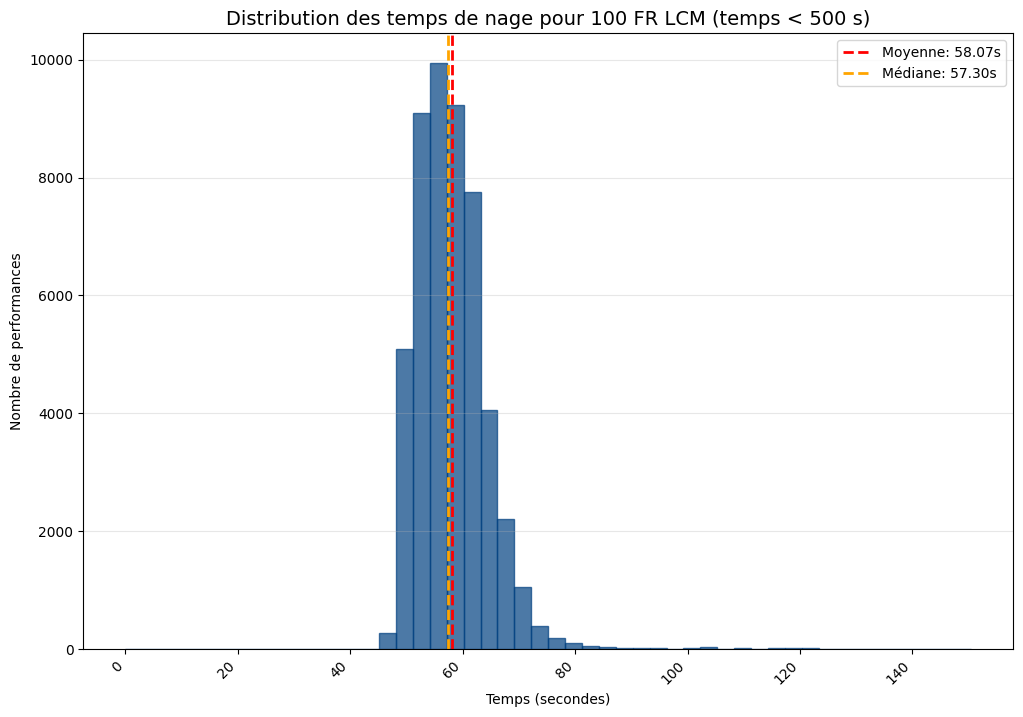

In [9]:
from matplotlib.ticker import MaxNLocator

nom_event = "100 FR LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) & 
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
].dropna()

print(f"Nombre de performances pour l'event {nom_event}: {len(swim_times)}")

fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(swim_times, bins=50, color="#004080", edgecolor="#004080", alpha=0.7)

mean_time = np.mean(swim_times)
median_time = np.median(swim_times)

ax.axvline(mean_time, color='red', linestyle='dashed', linewidth=2,
           label=f'Moyenne: {mean_time:.2f}s')
ax.axvline(median_time, color='orange', linestyle='dashed', linewidth=2,
           label=f'Médiane: {median_time:.2f}s')

ax.set_title(f"Distribution des temps de nage pour {nom_event} (temps < 500 s)", fontsize=14)
ax.set_xlabel("Temps (secondes)")
ax.set_ylabel("Nombre de performances")
ax.legend()

ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Histogram with Kernel Density Estimate (KDE)</h1>

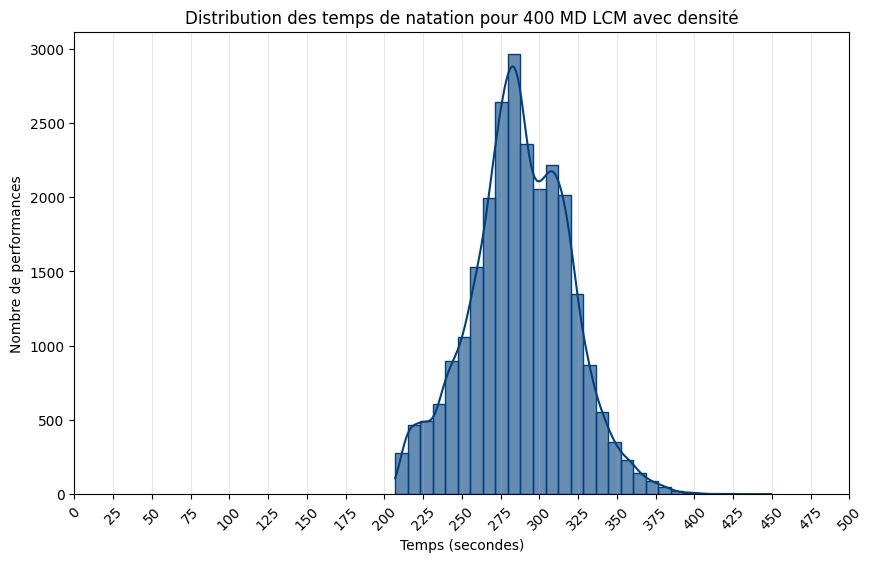

In [10]:
nom_event = "400 MD LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) & 
    (df["SwimTimeSeconds"].notna()) & 
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
]

plt.figure(figsize=(10,6))

sns.histplot(
    swim_times,
    bins=30,
    kde=True,
    color="#004080",
    edgecolor="#004080",
    alpha=0.6
)

plt.title(f"Distribution des temps de natation pour {nom_event} avec densité")
plt.xlabel("Temps (secondes)")
plt.ylabel("Nombre de performances")

plt.xticks(np.arange(0, 501, 25), rotation=45)
plt.grid(axis="x", alpha=0.3)

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Cumulative Histogram</h1>

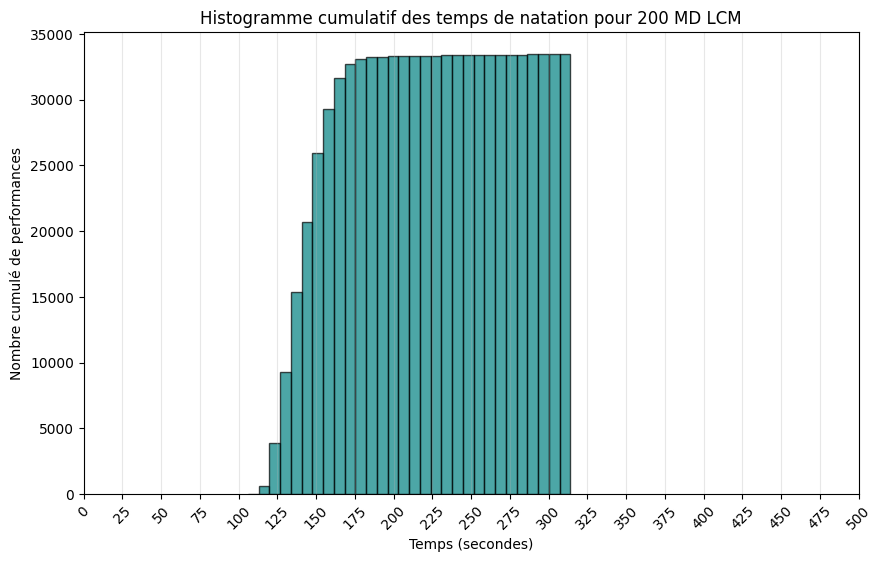

In [11]:
nom_event = "200 MD LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) &
    (df["SwimTimeSeconds"].notna()) &
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
]

if len(swim_times) > 0:
    plt.figure(figsize=(10,6))

    plt.hist(
        swim_times,
        bins=30,
        cumulative=True,
        color="#008080",
        edgecolor="black",
        alpha=0.7
    )

    plt.title(f"Histogramme cumulatif des temps de natation pour {nom_event}")
    plt.xlabel("Temps (secondes)")
    plt.ylabel("Nombre cumulé de performances")

    plt.xticks(np.arange(0, 501, 25), rotation=45)
    plt.grid(axis="x", alpha=0.3)

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

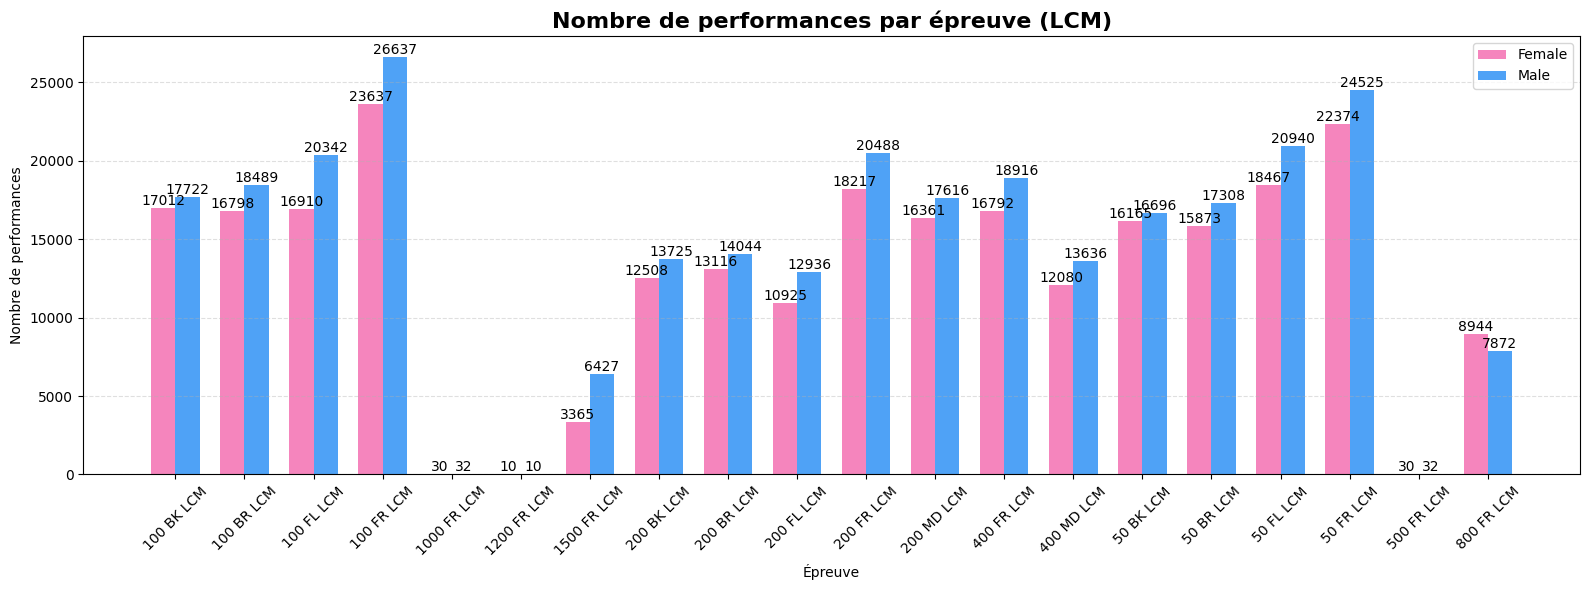

In [13]:
course_type = "LCM"

df["Gender"] = df["swimmer"].apply(
    lambda x: x[0].get("Gender") if isinstance(x, list) and len(x) > 0 else None
)

df["swimmer_name"] = df["swimmer"].apply(
    lambda x: x[0].get("Name") if isinstance(x, list) and len(x) > 0 else None
)

df_clean = df.dropna(subset=["Gender", "Event", "swimmer_name"])

df_clean = df_clean[df_clean["Event"].str.contains(course_type, na=False)]

df_counts = (
    df_clean
    .groupby(["Event", "Gender"])["swimmer_name"]
    .count()
    .unstack(fill_value=0)
    .sort_index()
)

events = df_counts.index

female_counts = df_counts["F"] if "F" in df_counts else pd.Series(0, index=events)
male_counts = df_counts["M"] if "M" in df_counts else pd.Series(0, index=events)

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(16, 6))

bars1 = plt.bar(
    x - width/2, female_counts, width,
    label="Female", color="#F585BD"
)

bars2 = plt.bar(
    x + width/2, male_counts, width,
    label="Male", color="#4FA2F6"
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title(
    f"Nombre de performances par épreuve ({course_type})",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Épreuve")
plt.ylabel("Nombre de performances")

plt.xticks(x, events, rotation=45)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

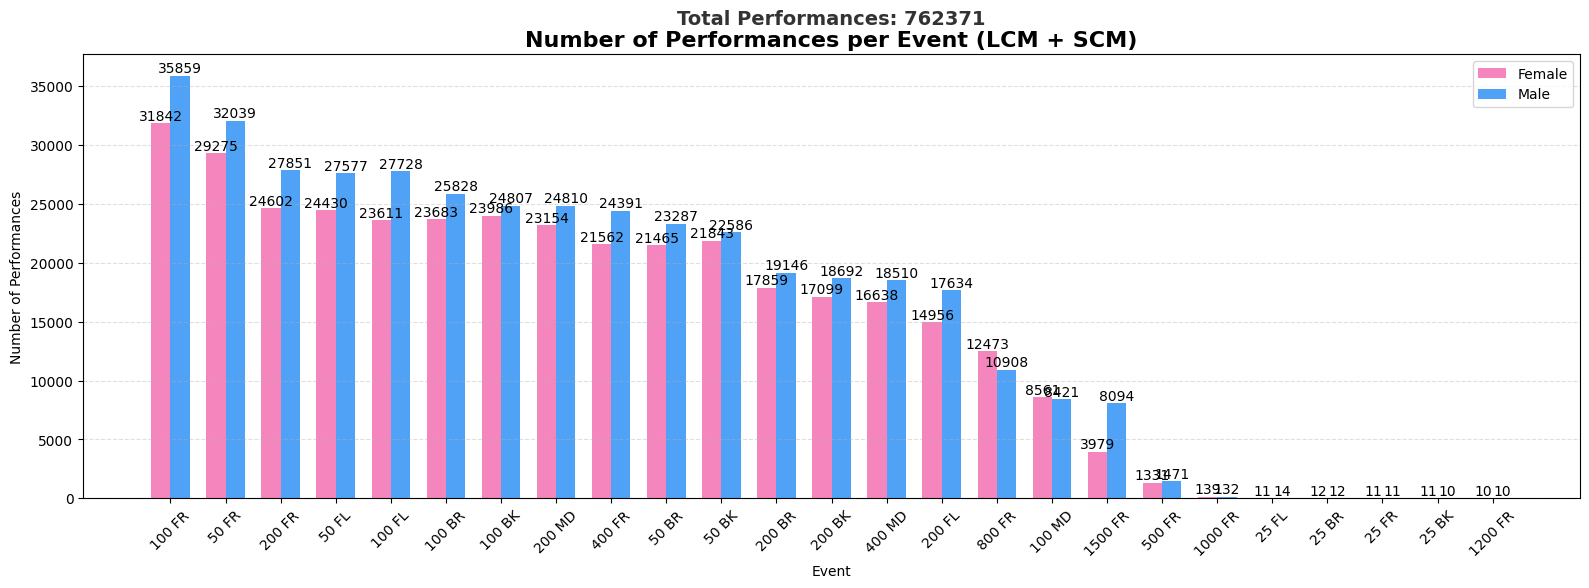

In [ ]:
df["Gender"] = df["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

df["Event_clean"] = df["Event"].str.replace(" LCM", "", regex=False)\
                               .str.replace(" SCM", "", regex=False)

df_clean = df.dropna(subset=["Gender", "Event_clean"])

df_counts = (
    df_clean
    .groupby(["Event_clean", "Gender"])
    .size()
    .unstack(fill_value=0)
)

df_counts["Total"] = df_counts.sum(axis=1)
df_counts = df_counts.sort_values("Total", ascending=False).drop(columns="Total")

total_performances = df_counts.sum().sum()

events = df_counts.index
female_counts = df_counts.get("F", [0]*len(events))
male_counts = df_counts.get("M", [0]*len(events))

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(16,6))

bars1 = plt.bar(x - width/2, female_counts, width, 
                label="Female", color="#F585BD")

bars2 = plt.bar(x + width/2, male_counts, width, 
                label="Male", color="#4FA2F6")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.1,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title("Number of Performances per Event (LCM + SCM)", fontsize=16, fontweight="bold")

plt.text(
    0.5, 1.08,
    f"Total Performances: {int(total_performances)}",
    ha='center',
    va='center',
    transform=plt.gca().transAxes,
    fontsize=14,
    fontweight='bold',
    color="#333333"
)

plt.xlabel("Event")
plt.ylabel("Number of Performances")
plt.xticks(x, events, rotation=45)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Countplot total number of performances by sex</h1>

Gender
M    399828
F    362543
Name: count, dtype: int64


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_3393/3315299978.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette=palette_colors)


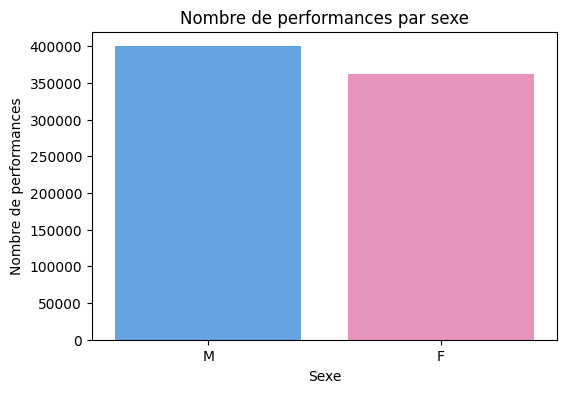

In [14]:
df["Gender"] = df["swimmer"].apply(lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None)

print(df["Gender"].value_counts())

plt.figure(figsize=(6,4))

palette_colors = {
    "F": "#F585BD",
    "M": "#4FA2F6"
}

sns.countplot(x="Gender", data=df, palette=palette_colors)

plt.title("Nombre de performances par sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre de performances")

plt.show()

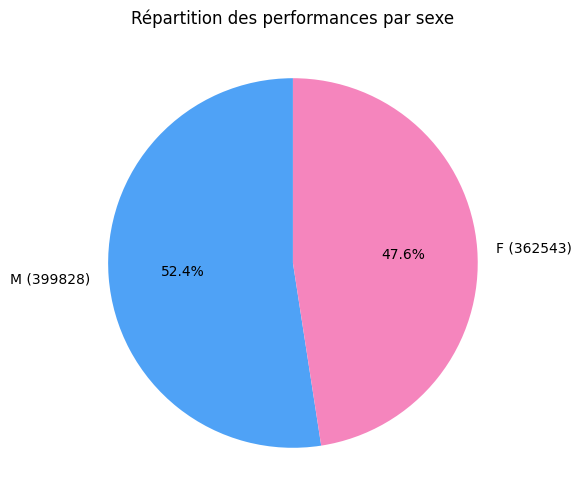

In [31]:
gender_counts = df["Gender"].value_counts()

colors = ["#4FA2F6","#F585BD"]

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Répartition des performances par sexe")

plt.show()

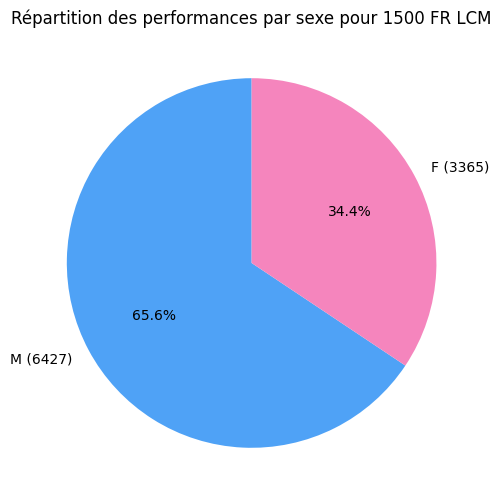

In [33]:
nom_event = "1500 FR LCM"

df_event = df[df["Event"] == nom_event].copy()

df_event["Gender"] = df_event["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

gender_counts = df_event["Gender"].value_counts()

if len(gender_counts) > 0:
    colors = ["#4FA2F6", "#F585BD"]

    plt.figure(figsize=(6,6))

    plt.pie(
        gender_counts,
        labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90
    )

    plt.title(f"Répartition des performances par sexe pour {nom_event}")
    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Boxplot (Boite à moustaches) du temps par stroke et la distance</h1>

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_61445/3648746993.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


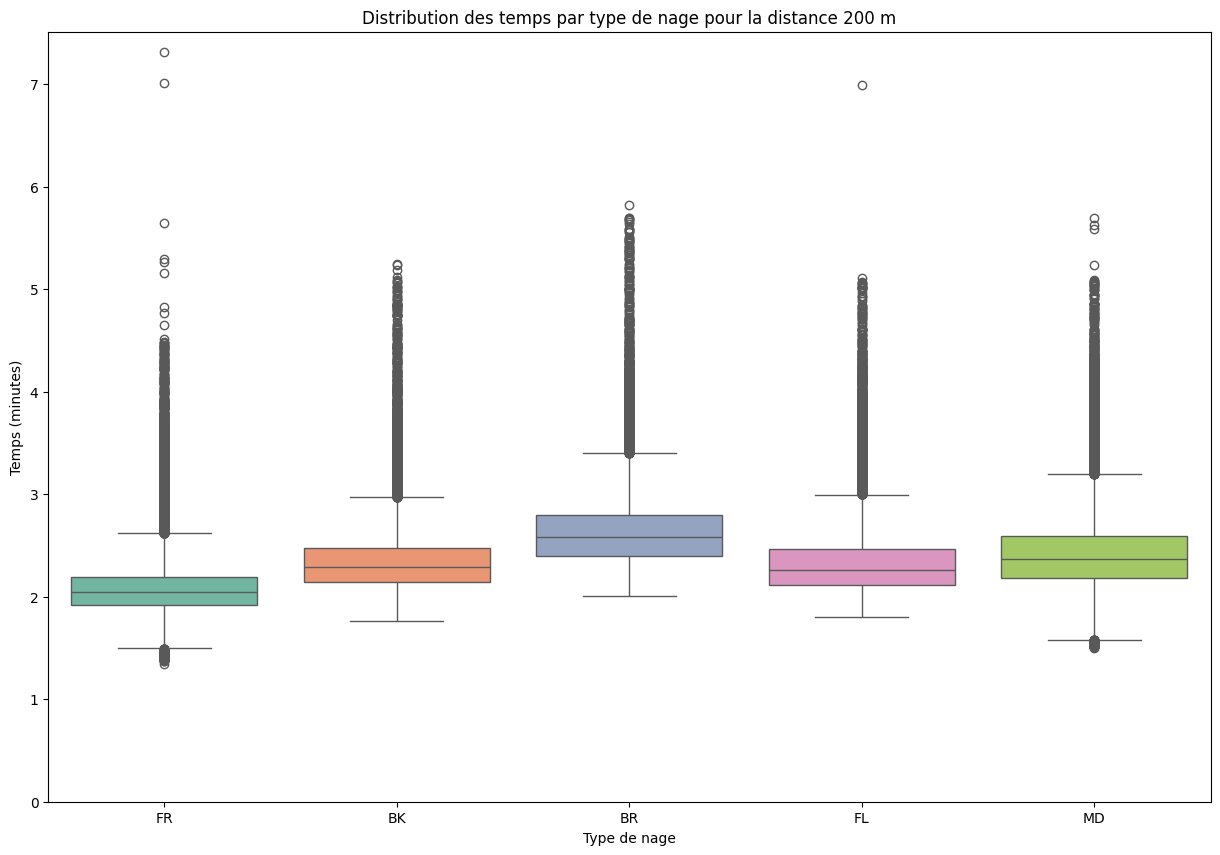

In [43]:
distance_choisie = 200

subset = df[
    (df["SwimTimeSeconds"].notna()) &
    (df["Distance"] == distance_choisie)
].copy()

if len(subset) > 0:
    subset["SwimTimeMinutes"] = subset["SwimTimeSeconds"] / 60

    plt.figure(figsize=(15, 10))
    sns.boxplot(
        x="Stroke",
        y="SwimTimeMinutes",
        data=subset,
        palette="Set2"
    )

    plt.title(f"Distribution des temps par type de nage pour la distance {distance_choisie} m")
    plt.xlabel("Type de nage")
    plt.ylabel("Temps (minutes)")
    plt.ylim(0, subset["SwimTimeMinutes"].max() + 0.2)

    plt.show()
else:
    print(f"Aucune donnée disponible pour la distance {distance_choisie} m")

<h1 style="color:#F0B4B4; font-size:32px;">Bar Chart: Number of Performances per Club</h1>

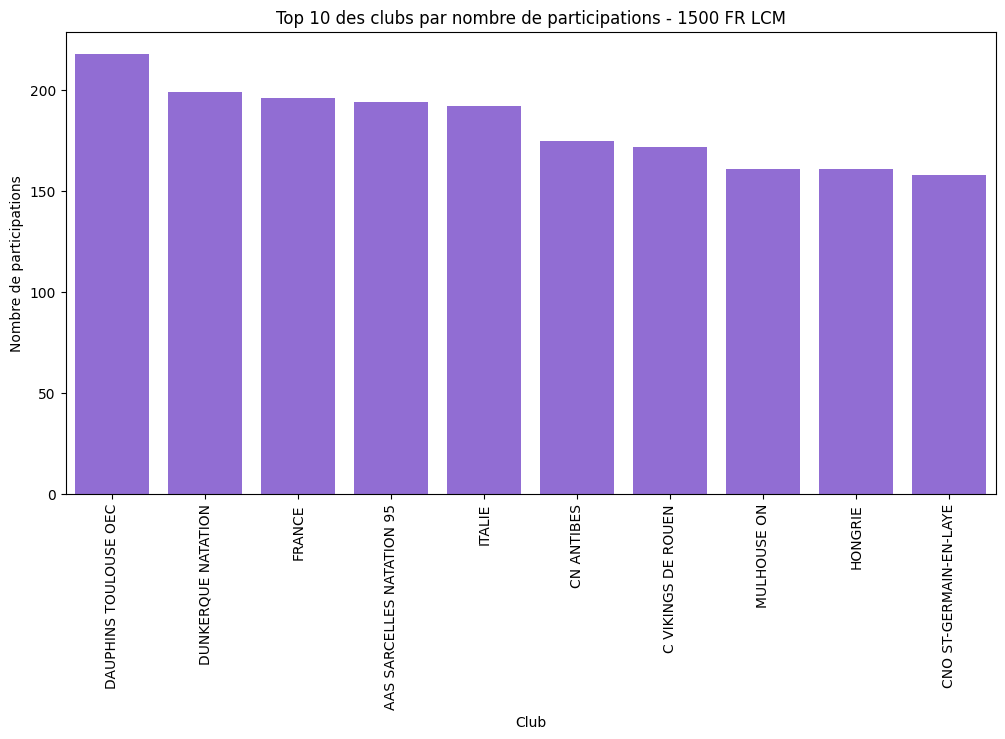

In [36]:
nom_event = "1500 FR LCM"

df_event = df[df["Event"] == nom_event]

top_clubs = df_event["Club"].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_clubs.index, y=top_clubs.values, color="#8C5CE4")

plt.title(f"Top 10 des clubs par nombre de participations - {nom_event}")
plt.xlabel("Club")
plt.ylabel("Nombre de participations")
plt.xticks(rotation=90)

plt.show()

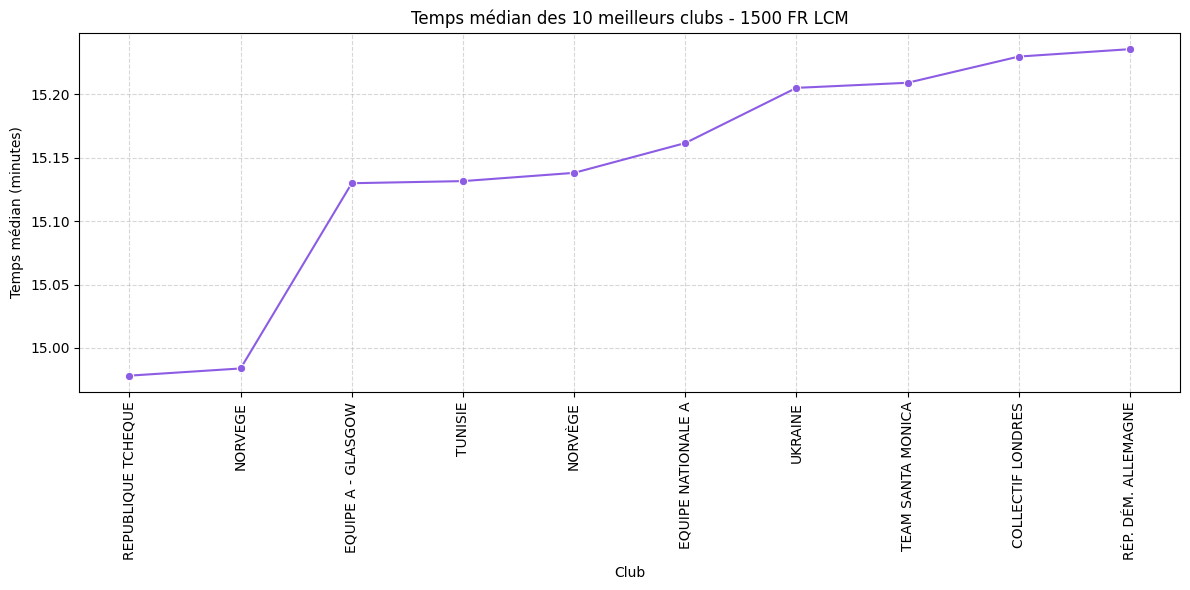

,Club,SwimTimeMinutes
508,REPUBLIQUE TCHEQUE,14.978167
466,NORVEGE,14.983833
292,EQUIPE A - GLASGOW,15.129833
610,TUNISIE,15.131500
467,NORVÈGE,15.138000
295,EQUIPE NATIONALE A,15.161500
613,UKRAINE,15.205000
599,TEAM SANTA MONICA,15.209000
240,COLLECTIF LONDRES,15.229667
514,RÉP. DÉM. ALLEMAGNE,15.235500


In [103]:
nom_event = "1500 FR LCM"

df_time = df[
    (df["Event"] == nom_event)
    & (df["SwimTimeSeconds"].notna())
].copy()

df_time["SwimTimeMinutes"] = df_time["SwimTimeSeconds"] / 60

median_time_club = (
    df_time.groupby("Club", dropna=False)["SwimTimeMinutes"]
    .median()
    .reset_index()
    .sort_values("SwimTimeMinutes")
)

top10_clubs = median_time_club.head(10)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=top10_clubs,
    x="Club",
    y="SwimTimeMinutes",
    marker="o",
    color="#8C5CE4"
)

plt.title(f"Temps médian des 10 meilleurs clubs - {nom_event}")
plt.xlabel("Club")
plt.ylabel("Temps médian (minutes)")
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

display(top10_clubs)

<h1 style="color:#F0B4B4; font-size:32px;">Line Plot of Swim Times by Stroke Type Over Time for a Sample of 5000</h1>

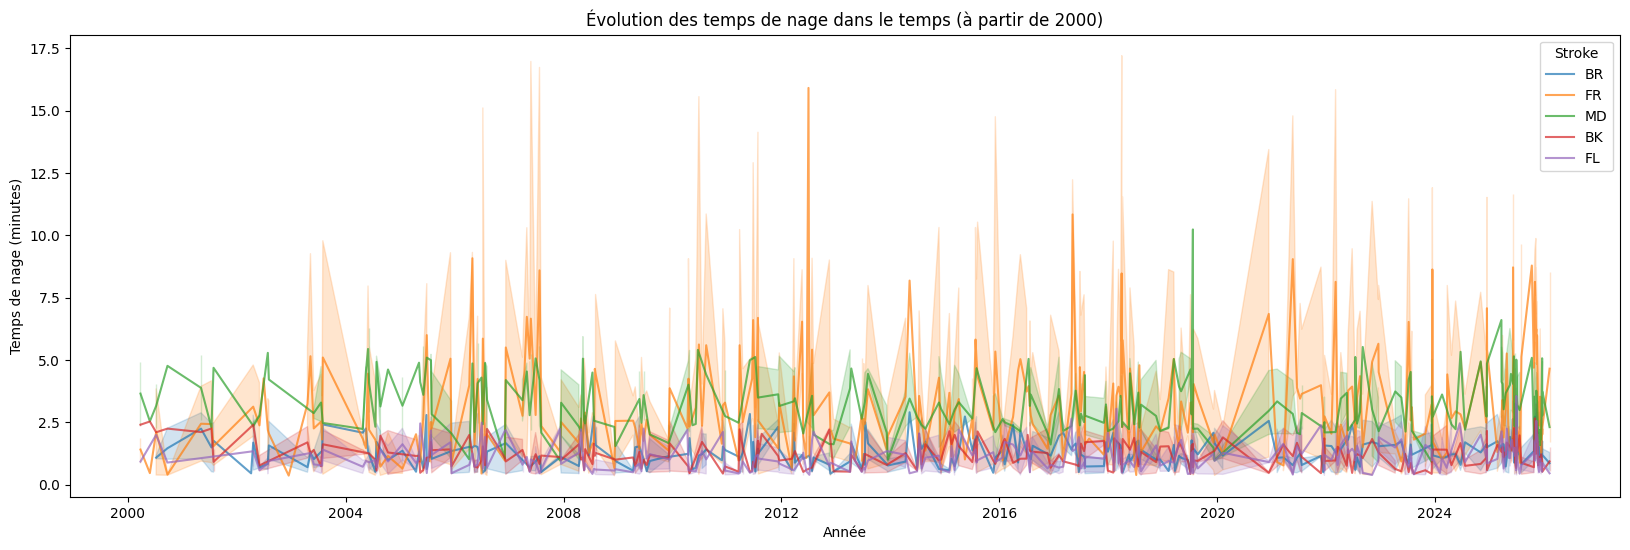

In [7]:
df["SwimDate"] = pd.to_datetime(df["SwimDate"], errors="coerce")

df_plot = df[
    (df["SwimDate"].notna())
    & (df["SwimTimeSeconds"].notna())
    & (df["SwimDate"].dt.year >= 2000)
].copy()

df_plot["SwimTimeMinutes"] = df_plot["SwimTimeSeconds"] / 60

plt.figure(figsize=(20, 6))
sns.lineplot(
    x="SwimDate",
    y="SwimTimeMinutes",
    data=df_plot.sample(min(5000, len(df_plot)), random_state=42),
    hue="Stroke",
    alpha=0.7
)

plt.title("Évolution des temps de nage dans le temps (à partir de 2000)")
plt.xlabel("Année")
plt.ylabel("Temps de nage (minutes)")
plt.legend(title="Stroke")
plt.show()

In [8]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'], errors='coerce')

df['Year'] = df['SwimDate'].dt.year

min_year = df['Year'].min()

print("L'année la plus ancienne est :", min_year)

L'année la plus ancienne est : 1976


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_17893/2538075256.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


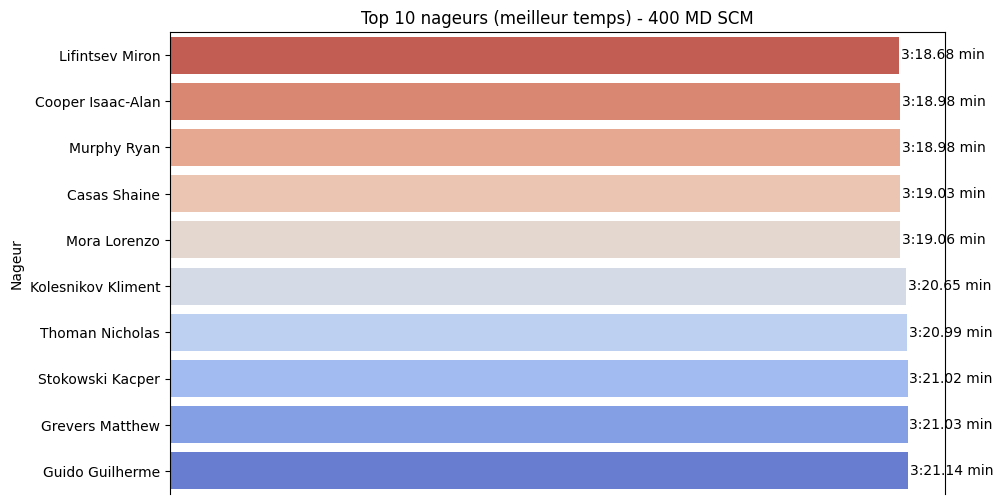

In [15]:
nom_event = "400 MD SCM"

subset = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['SwimTimeSeconds'] > 0)
].copy()

if len(subset) > 0:
    subset['SwimmerName'] = subset['swimmer'].apply(
        lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else "Unknown"
    )

    best_times = subset.groupby('SwimmerName', as_index=False)['SwimTimeSeconds'].min()

    top10 = best_times.nsmallest(10, 'SwimTimeSeconds')

    def format_time(sec):
        minutes = int(sec // 60)
        seconds = sec % 60
        return f"{minutes}:{seconds:05.2f} min"

    plt.figure(figsize=(10,6))
    ax = sns.barplot(
        x='SwimTimeSeconds',
        y='SwimmerName',
        data=top10,
        palette="coolwarm_r",
        orient='h',
        errorbar=None
    )

    plt.title(f"Top 10 nageurs (meilleur temps) - {nom_event}")
    plt.ylabel("Nageur")

    ax.set_xlabel("")
    ax.set_xticks([])
    ax.spines['bottom'].set_visible(False)

    for i, v in enumerate(top10['SwimTimeSeconds']):
        ax.text(v + 0.5, i, format_time(v), va='center')

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of Speed Performance Across Distances by Stroke</h1>

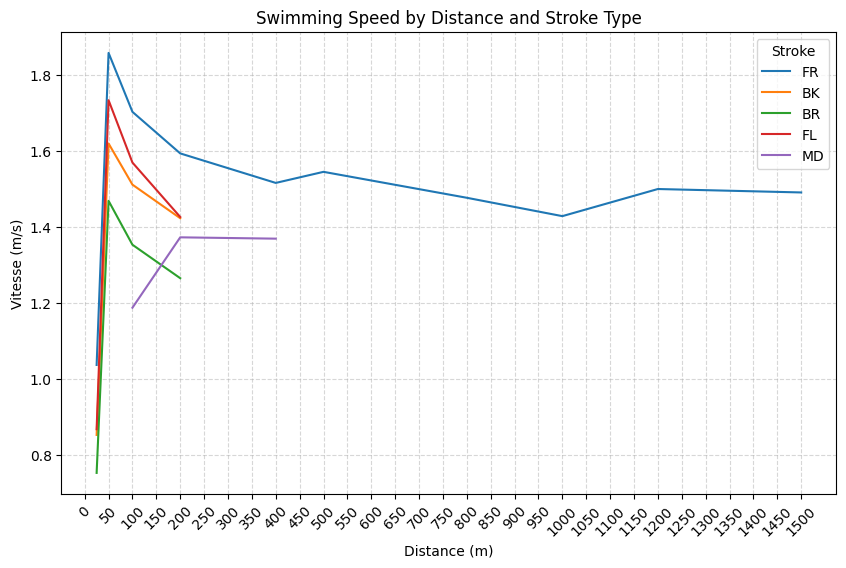

In [55]:
df_speed = df[df['Speed'].notna()]

plt.figure(figsize=(10,6))

sns.lineplot(
    x='Distance',
    y='Speed',
    hue='Stroke',
    data=df_speed,
    errorbar=None
)

max_distance = int(df_speed['Distance'].max())
plt.xticks(np.arange(0, max_distance + 50, 50), rotation=45)

plt.title("Swimming Speed by Distance and Stroke Type")
plt.xlabel("Distance (m)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Max Speed per Split Distance and Stroke:


,Swimmer,Stroke,SplitDistance,SplitSpeed
0,Baroni Clement,BK,50,2.784
1,Olivié Nicolas,BK,100,3.228
2,Arhab Botko Mathilde,BK,150,2.266
3,Adjesson Aaliyah,BK,200,2.323
4,Tateishi Ryo,BR,50,2.160
5,Jacquot Raphael,BR,100,3.008
6,Gyurta Daniel,BR,150,1.620
7,Banchereau Léana,BR,200,3.623
8,Ienny Marianne,FL,50,2.950
9,Poirier Lenaïg,FL,100,4.713


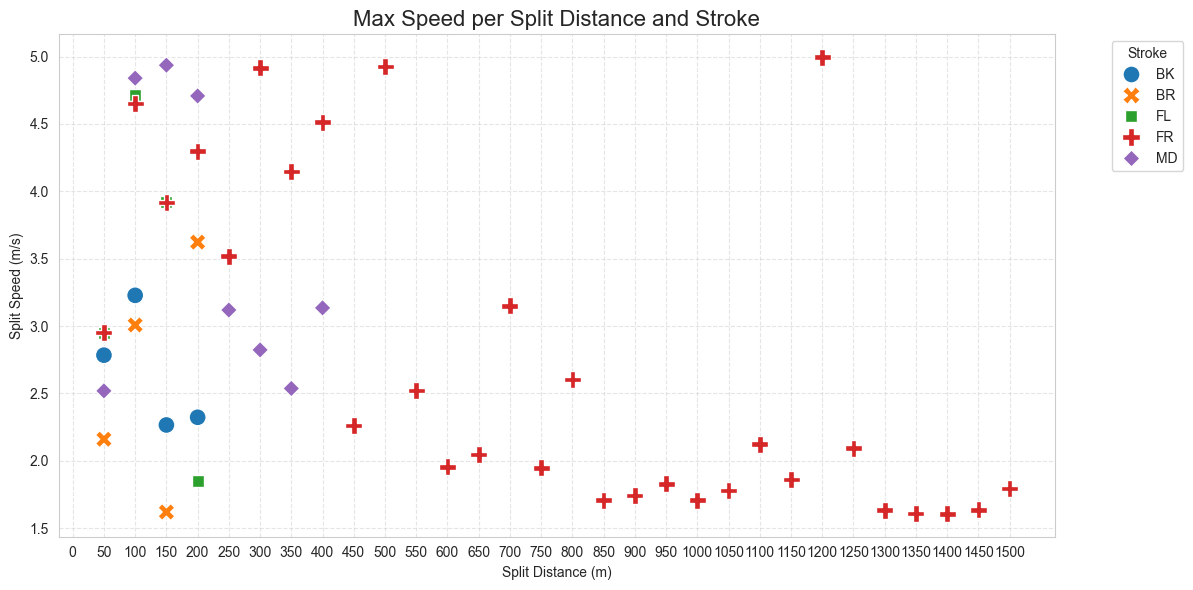

In [7]:
import mplcursors
df_clean = df.loc[df['Speed'].notna(), ['Stroke', 'Distance', 'Speed', 'swimmer', 'splits']].copy()

def clean_swimmer(x):
    if isinstance(x, dict):
        return x.get('Name')
    elif isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict):
        return x[0].get('Name')
    return None

df_clean['Swimmer'] = df_clean['swimmer'].map(clean_swimmer)
df_clean = df_clean.dropna(subset=['Swimmer'])

df_split = []

for _, row in df_clean.loc[df_clean['splits'].apply(lambda x: isinstance(x, list) and len(x) > 0)].iterrows():
    swimmer_name = row['Swimmer']
    stroke = row['Stroke']
    
    for s in row['splits']:
        split_distance = s.get('split_distance')
        split_speed = s.get('split_speed')
        
        if split_distance is not None and split_speed is not None:
            try:
                dist = int(str(split_distance).replace(' m', ''))
                speed = float(split_speed)
                if 0 < speed < 5:
                    df_split.append({
                        'Stroke': stroke,
                        'SplitDistance': dist,
                        'SplitSpeed': speed,
                        'Swimmer': swimmer_name
                    })
            except:
                continue

df_splits = pd.DataFrame(df_split)

df_splits_max = df_splits.loc[
    df_splits.groupby(['Stroke', 'SplitDistance'])['SplitSpeed'].idxmax()
].reset_index(drop=True)

print("Max Speed per Split Distance and Stroke:")
display(df_splits_max[['Swimmer', 'Stroke', 'SplitDistance', 'SplitSpeed']])

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

ax = sns.scatterplot(
    data=df_splits_max,
    x='SplitDistance',
    y='SplitSpeed',
    hue='Stroke',
    style='Stroke',
    s=150
)

max_split = int(df_splits_max['SplitDistance'].max())
plt.xticks(np.arange(0, max_split + 50, 50))

points = df_splits_max[['SplitDistance', 'SplitSpeed', 'Swimmer', 'Stroke']].values

cursor = mplcursors.cursor(ax.collections, hover=True)

@cursor.connect("add")
def on_add(sel):
    x, y = sel.target
    distances = (points[:, 0] - x)**2 + (points[:, 1] - y)**2
    idx = distances.argmin()
    
    sel.annotation.set_text(
        f"{points[idx][2]}\n"
        f"Stroke: {points[idx][3]}\n"
        f"Split Distance: {int(points[idx][0])} m\n"
        f"Split Speed: {points[idx][1]:.2f} m/s"
    )

plt.title("Max Speed per Split Distance and Stroke", fontsize=16)
plt.xlabel("Split Distance (m)")
plt.ylabel("Split Speed (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Stroke", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Heatmap of Average Swim Speed by Distance and Stroke</h1>

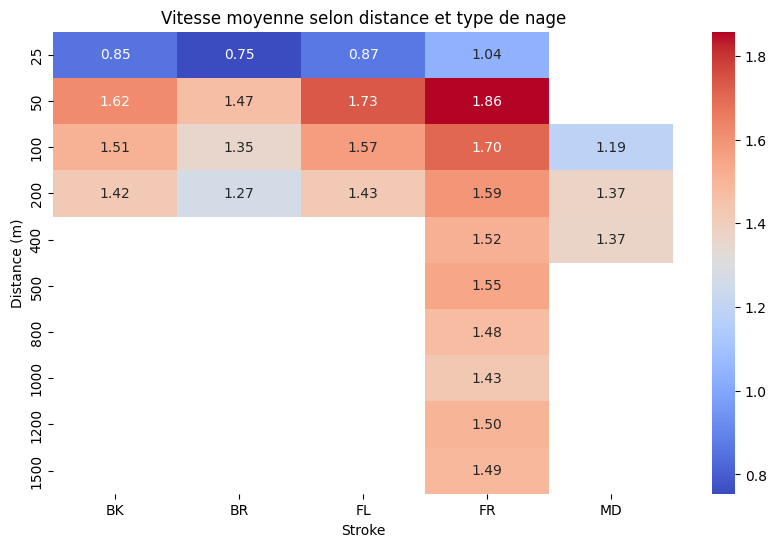

In [5]:
pivot = df.pivot_table(
    values='Speed',
    index='Distance',
    columns='Stroke',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Vitesse moyenne selon distance et type de nage")
plt.xlabel("Stroke")
plt.ylabel("Distance (m)")

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of Speed ​​per split for a precise Swimmer and Event</h1>

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_17893/3746562417.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


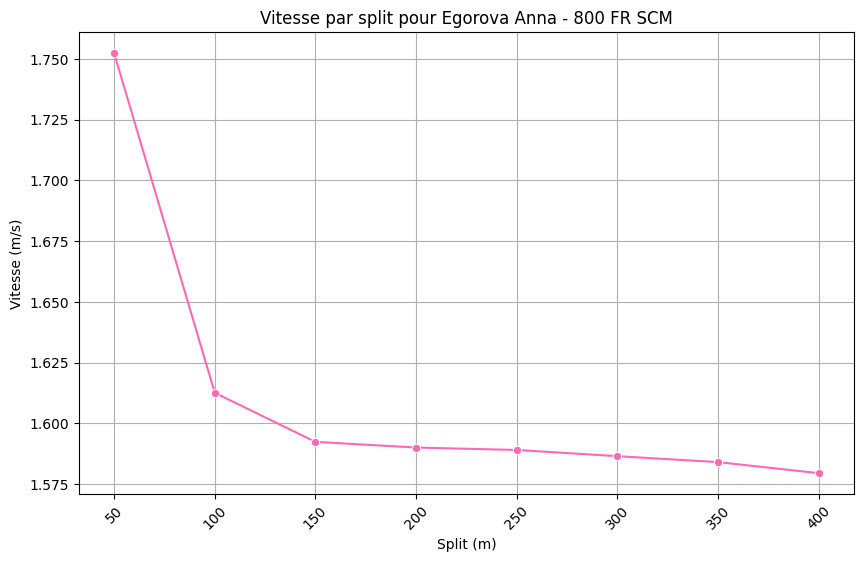

In [28]:
nom_nageur = "Egorova Anna"
nom_event = "800 FR SCM"

split_data = []
gender_nageur = None  

for idx, row in df.iterrows():
    if row['Event'] == nom_event and len(row['swimmer']) == 1:
        swimmer = row['swimmer'][0]
        if swimmer['Name'] == nom_nageur:
            gender_nageur = swimmer.get('Gender')  
            for s in row['splits']:
                if s['split_speed'] is not None:
                    dist = int(s['split_distance'].replace(' m',''))
                    split_data.append({
                        'split_distance': dist,
                        'split_speed': s['split_speed']
                    })

df_splits = pd.DataFrame(split_data)

df_splits = df_splits.sort_values('split_distance')

if gender_nageur == "M":
    color_line = "#003E80"  
elif gender_nageur == "F":
    color_line = "#FF69B4"  
else:
    color_line = "#008080"  

plt.figure(figsize=(10,6))
sns.lineplot(
    x='split_distance',
    y='split_speed',
    data=df_splits,
    marker='o',
    color=color_line,
    ci=None  
)
plt.xticks(range(50, df_splits['split_distance'].max()+50, 50), rotation=45) 
plt.title(f"Vitesse par split pour {nom_nageur} - {nom_event}")
plt.xlabel("Split (m)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True)
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmers for a specific event</h1>

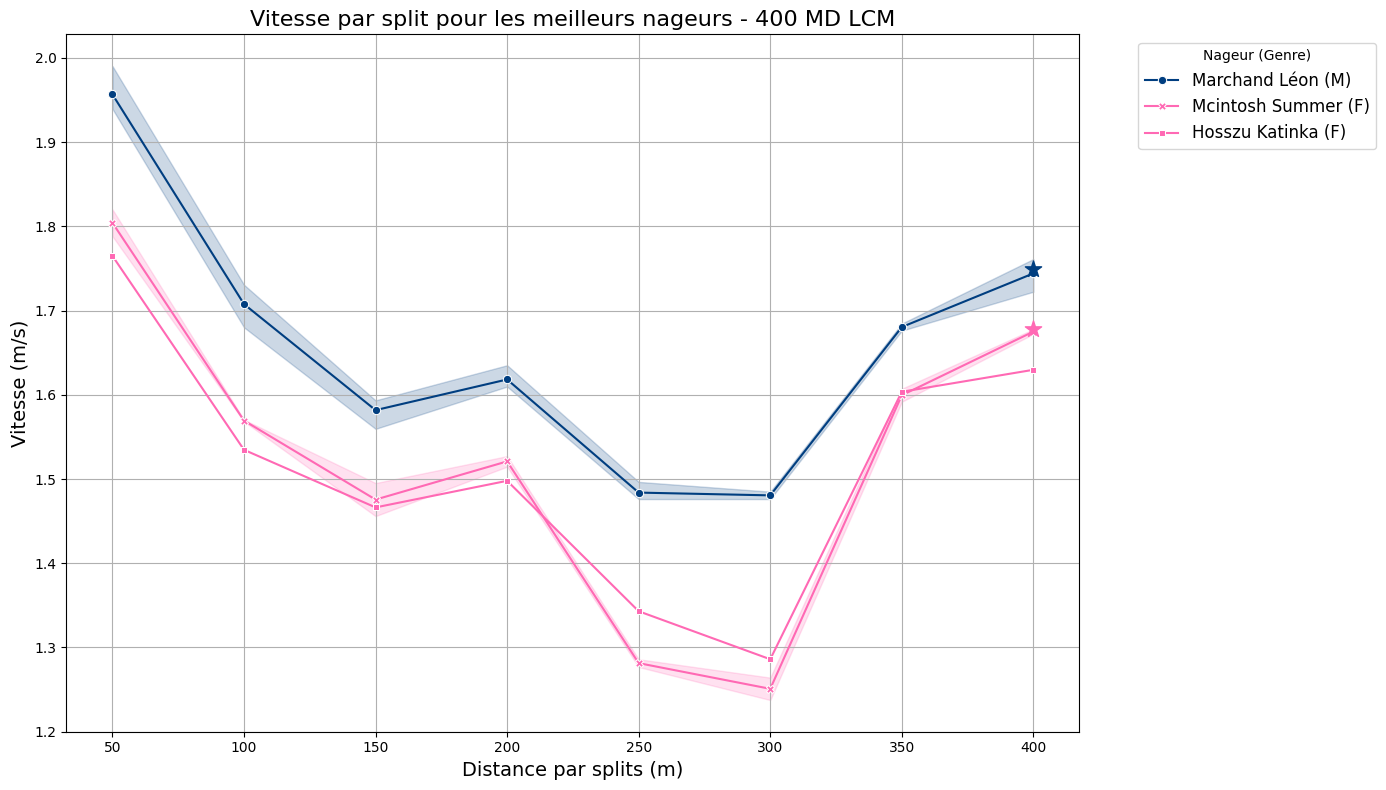

In [49]:
nom_event = "400 MD LCM"
top_n = 3  

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')

df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    swimmer_name = row['swimmer_name']
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_speed'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'swimmer': swimmer_name,
                    'gender': gender,
                    'split_distance': dist,
                    'split_speed': s['split_speed']
                })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucun split valide trouvé pour les top nageurs.")
else:
    df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

    palette_colors = {'M': "#003E80", 'F': "#FF69B4"}
    palette_for_plot = {label: palette_colors[gender] for label, gender in zip(df_splits['swimmer_label'], df_splits['gender'])}

    plt.figure(figsize=(14,8))
    sns.lineplot(
        x='split_distance',
        y='split_speed',
        hue='swimmer_label',
        style='swimmer_label',
        data=df_splits,
        markers=True,
        dashes=False,
        palette=palette_for_plot
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour les meilleurs nageurs - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

    best_male = df_top_men.nsmallest(1, 'SwimTimeSeconds')['swimmer_name'].values[0]
    best_female = df_top_women.nsmallest(1, 'SwimTimeSeconds')['swimmer_name'].values[0]

    for swimmer in [best_male, best_female]:
        swimmer_data = df_splits[df_splits['swimmer'] == swimmer]
        color = palette_for_plot[swimmer + f" ({swimmer_data['gender'].iloc[0]})"]

        plt.scatter(
            swimmer_data['split_distance'].iloc[-1],
            swimmer_data['split_speed'].iloc[-1],
            s=150,  
            color=color,
            marker='*',
            zorder=5
        )

    plt.tight_layout()
    plt.show()

In [31]:
df_event = df[
    (df['Event'] == "1500 FR LCM") &
    (df['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1) &
     df['splits'].apply(lambda x: isinstance(x, list) and len(x) == 15))
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

swimmers_in_event = df_event[['swimmer_name', 'swimmer_gender']].drop_duplicates()

print(len(swimmers_in_event))
# y a des nageurs qui n ont pas tous les splits

947


<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmers for a specific event (women vs men)</h1>

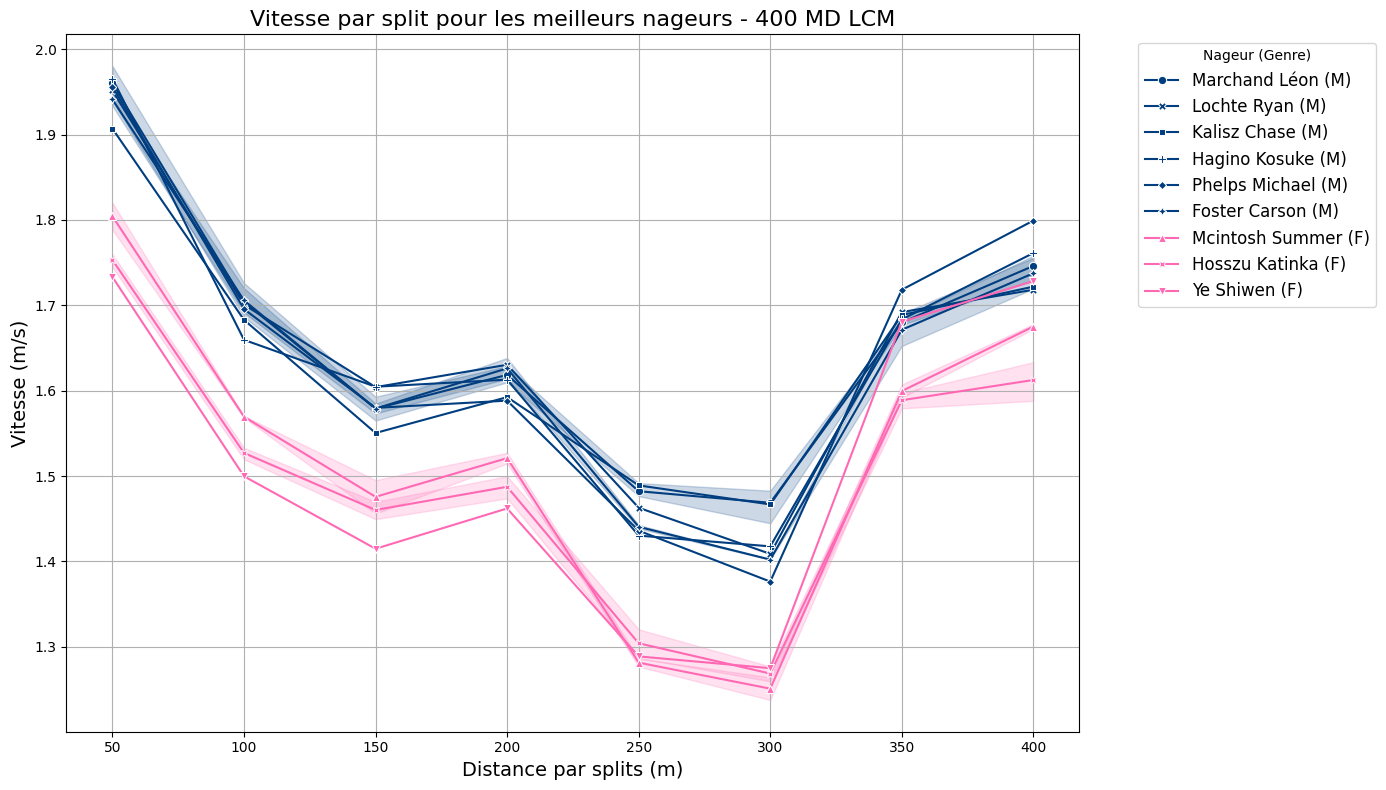

In [50]:
nom_event = "400 MD LCM"  
top_n = 10                

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')

df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    swimmer_name = row['swimmer_name']
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits: 
        for s in splits:
            if s['split_speed'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'swimmer': swimmer_name,
                    'gender': gender,
                    'split_distance': dist,
                    'split_speed': s['split_speed']
                })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucun split valide trouvé pour les top nageurs.")
else:
    df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

    palette_colors = {'M': "#003E80", 'F': "#FF69B4"}

    palette_for_plot = {label: palette_colors[gender] for label, gender in zip(df_splits['swimmer_label'], df_splits['gender'])}

    plt.figure(figsize=(14,8))
    sns.lineplot(
        x='split_distance',
        y='split_speed',
        hue='swimmer_label',
        style='swimmer_label',
        data=df_splits,
        markers=True,
        dashes=False,
        palette=palette_for_plot
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour les meilleurs nageurs - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmer in a given event</h1>

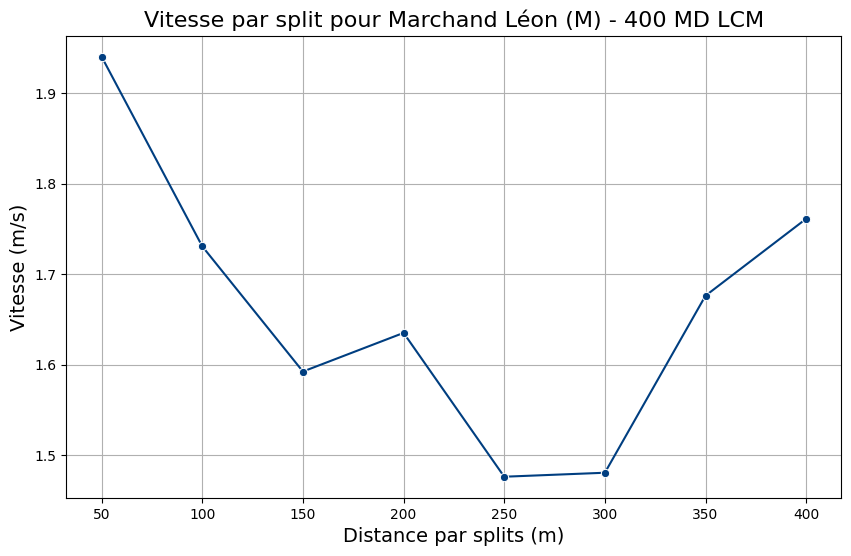

In [46]:
nom_event = "400 MD LCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]

best_name = df_best['swimmer_name']
best_gender = df_best['swimmer_gender']
best_splits = df_best['splits']

split_data = []
for s in best_splits:
    if s['split_speed'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_data.append({
            'split_distance': dist,
            'split_speed': s['split_speed']
        })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print(f"Aucun split valide trouvé pour le meilleur nageur de l'Event {nom_event}.")
else:
    plt.figure(figsize=(10,6))
    color = "#003E80" if best_gender == 'M' else "#FF69B4"

    sns.lineplot(
        x='split_distance',
        y='split_speed',
        data=df_splits,
        marker='o',
        color=color
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour {best_name} ({best_gender}) - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of average of swim time by splits</h1>

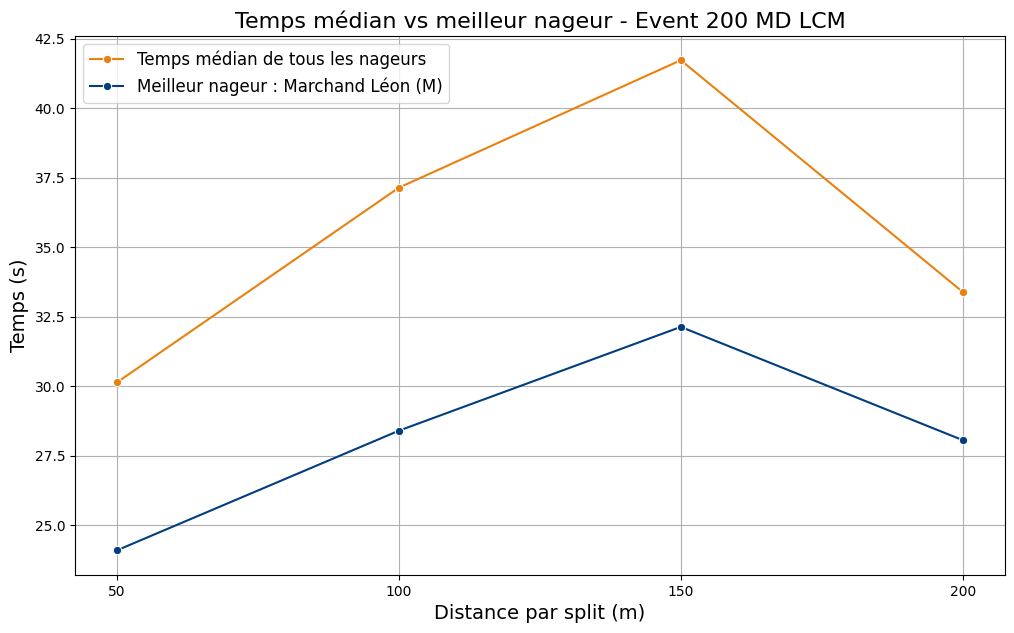

In [ ]:
nom_event = "200 MD LCM"  

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_median_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].median()

# Meilleur nageur
df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]
best_name = df_best['swimmer'][0]['Name']
best_gender = df_best['swimmer'][0]['Gender']
best_splits = df_best['splits']

split_best_data = []
for s in best_splits:
    if s['split_seconds'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_best_data.append({
            'split_distance': dist,
            'split_seconds': s['split_seconds']
        })

df_best_splits = pd.DataFrame(split_best_data)

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_median_splits,
    marker='o',
    color="#EA800F",
    label="Temps médian de tous les nageurs"
)

color_best = "#003E80" if best_gender == 'M' else "#FF69B4"
sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_best_splits,
    marker='o',
    color=color_best,
    label=f"Meilleur nageur : {best_name} ({best_gender})"
)

plt.xticks(range(
    50,
    max(df_median_splits['split_distance'].max(), df_best_splits['split_distance'].max()) + 50,
    50
))

plt.title(f"Temps médian vs meilleur nageur - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)

plt.show()

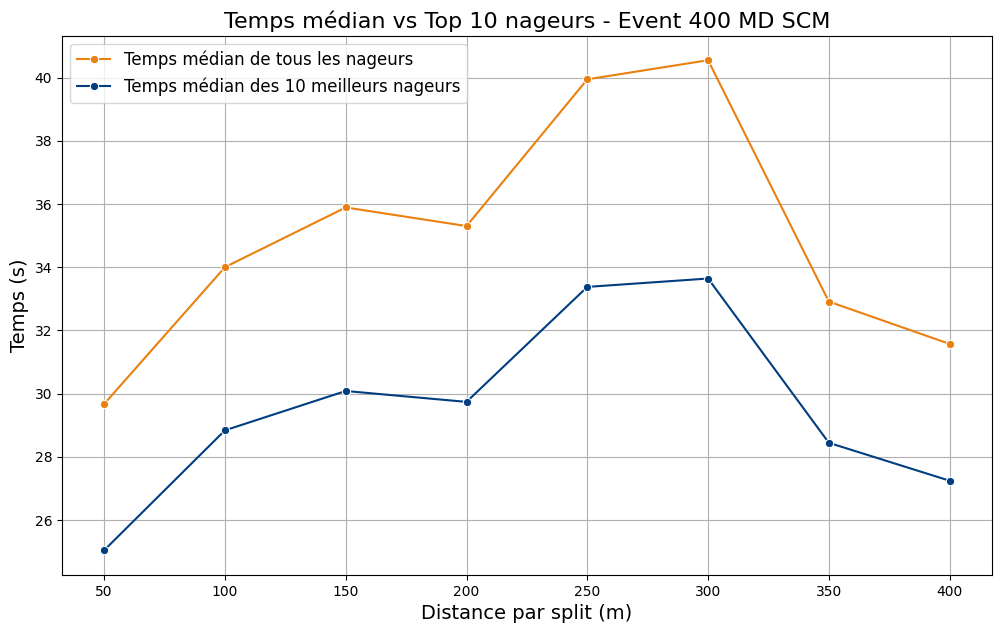

In [ ]:
nom_event = "400 MD SCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_median_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].median()

# Top 10 nageurs
df_top10 = df_event.nsmallest(10, 'SwimTimeSeconds')

top10_split_data = []

for idx, row in df_top10.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                top10_split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_top10_splits = pd.DataFrame(top10_split_data)

df_top10_median = df_top10_splits.groupby('split_distance', as_index=False)['split_seconds'].median()

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_median_splits,
    marker='o',
    color="#EA800F",
    label="Temps médian de tous les nageurs"
)

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_top10_median,
    marker='o',
    color="#003E80",
    label="Temps médian des 10 meilleurs nageurs"
)

plt.xticks(range(
    50,
    max(df_median_splits['split_distance'].max(),
        df_top10_median['split_distance'].max()) + 50,
    50
))

plt.title(f"Temps médian vs Top 10 nageurs - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)

plt.grid(True)
plt.legend(fontsize=12)

plt.show()

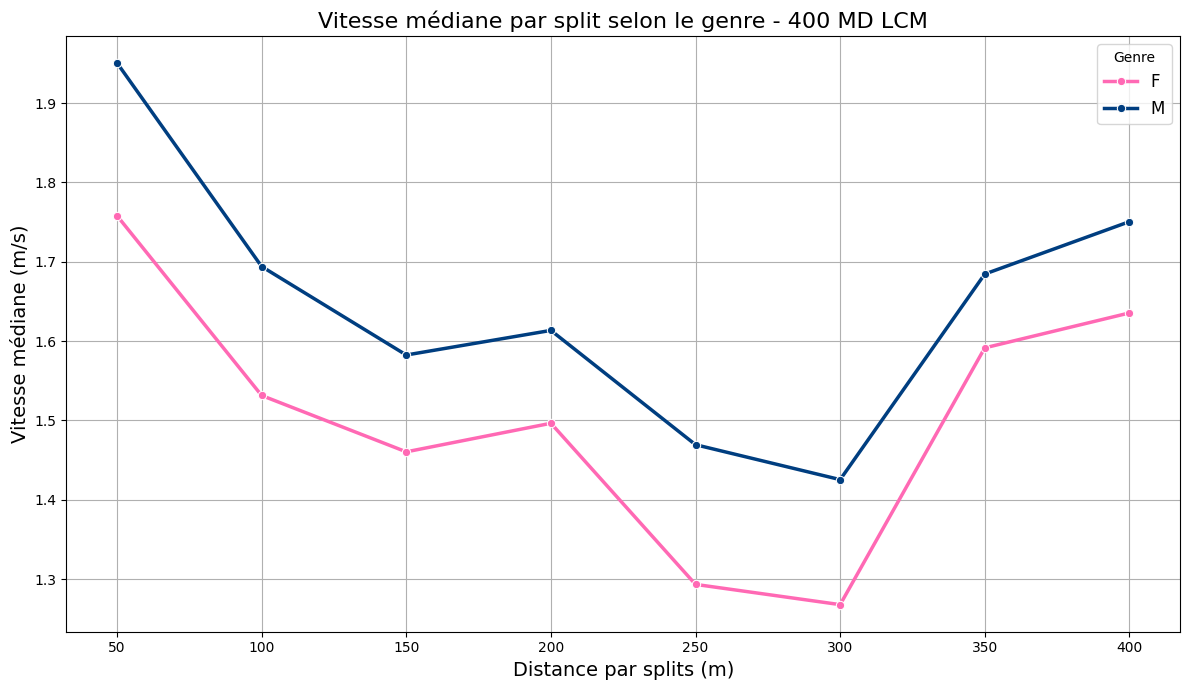

In [108]:
nom_event = "400 MD LCM"
top_n = 10

df_event = df[
    (df["Event"] == nom_event) &
    (df["SwimTimeSeconds"].notna()) &
    (df["swimmer"].apply(lambda x: isinstance(x, list) and len(x) == 1))
].copy()

df_event["swimmer_name"] = df_event["swimmer"].apply(lambda x: x[0]["Name"])
df_event["swimmer_gender"] = df_event["swimmer"].apply(lambda x: x[0]["Gender"])

df_top_men = df_event[df_event["swimmer_gender"] == "M"].nsmallest(top_n, "SwimTimeSeconds")
df_top_women = df_event[df_event["swimmer_gender"] == "F"].nsmallest(top_n, "SwimTimeSeconds")
df_top_all = pd.concat([df_top_men, df_top_women], ignore_index=True)

split_data = []
for _, row in df_top_all.iterrows():
    gender = row["swimmer_gender"]
    splits = row["splits"]

    if isinstance(splits, list):
        for s in splits:
            if not isinstance(s, dict):
                continue
            try:
                dist = int(str(s.get("split_distance")).replace(" m", "").strip())
            except (ValueError, TypeError):
                continue

            split_speed = s.get("split_speed")
            if split_speed is None:
                continue

            try:
                split_speed = float(split_speed)
            except (ValueError, TypeError):
                continue

            split_data.append({
                "gender": gender,
                "split_distance": dist,
                "split_speed": split_speed
            })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucune donnée de split exploitable.")
else:
    df_med = (
        df_splits
        .groupby(["gender", "split_distance"])["split_speed"]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(12, 7))
    palette_colors = {"M": "#003E80", "F": "#FF69B4"}

    sns.lineplot(
        x="split_distance",
        y="split_speed",
        hue="gender",
        data=df_med,
        marker="o",
        palette=palette_colors,
        linewidth=2.5
    )

    plt.xticks(range(50, int(df_splits["split_distance"].max()) + 50, 50))
    plt.title(f"Vitesse médiane par split selon le genre - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse médiane (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title="Genre", fontsize=12)
    plt.tight_layout()
    plt.show()

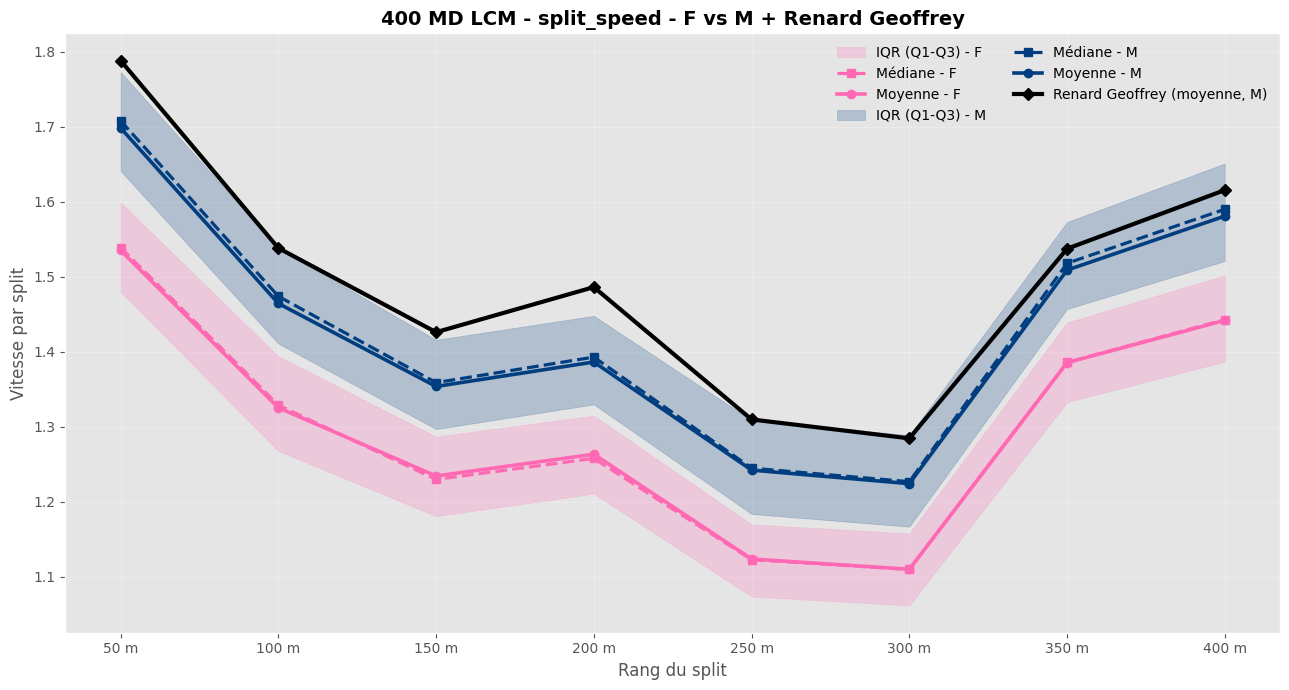

,Gender,split_no,split_distance_theorique,mean,median,q1,q3,n
0,F,1,50,1.5352,1.539,1.480,1.599,7533
1,F,2,100,1.3255,1.329,1.268,1.394,7533
2,F,3,150,1.2345,1.230,1.181,1.287,7533
3,F,4,200,1.2636,1.258,1.211,1.315,7533
4,F,5,250,1.1240,1.123,1.074,1.170,7533
5,F,6,300,1.1102,1.110,1.062,1.158,7533
6,F,7,350,1.3856,1.386,1.333,1.439,7533
7,F,8,400,1.4419,1.443,1.387,1.502,7533
8,M,1,50,1.6984,1.708,1.641,1.773,8401
9,M,2,100,1.4645,1.474,1.411,1.538,8401


,Gender,split_no,split_distance_theorique,target_mean,target_n
0,M,1,50,1.7882,58
1,M,2,100,1.5383,58
2,M,3,150,1.4262,58
3,M,4,200,1.4863,58
4,M,5,250,1.3099,58
5,M,6,300,1.2847,58
6,M,7,350,1.5374,58
7,M,8,400,1.6155,58



Nombre de lignes splits pour Renard Geoffrey : 464
Nombre de performances (approx) : 58

Nombre de performances retenues : 20129
Nombre total de valeurs split_speed : 127472


In [15]:
import matplotlib.colors as mcolors

nom_event = "400 MD LCM"
palette = {"F": "#FF69B4", "M": "#003E80"}

swimmer_target = "Renard Geoffrey"

expected = ["50 m", "100 m", "150 m", "200 m", "250 m", "300 m", "350 m", "400 m"]

def adjust_color(color, factor=1.0):
    r, g, b = mcolors.to_rgb(color)
    if factor >= 1:
        r = r + (1 - r) * (factor - 1)
        g = g + (1 - g) * (factor - 1)
        b = b + (1 - b) * (factor - 1)
    else:
        r *= factor
        g *= factor
        b *= factor
    return (min(max(r, 0), 1), min(max(g, 0), 1), min(max(b, 0), 1))

def parse_dist(x):
    try:
        return int(str(x).replace(" m", "").strip())
    except Exception:
        return None

def normalize_name(x):
    return str(x).strip().lower() if pd.notna(x) else ""

def has_expected_prefix(splits, expected_list):
    if not isinstance(splits, list) or len(splits) < len(expected_list):
        return False
    for i, exp in enumerate(expected_list):
        si = splits[i]
        if not isinstance(si, dict):
            return False
        if str(si.get("split_distance")).strip() != exp:
            return False
        if si.get("split_speed") is None:
            return False
    return True

df_event = df[
    (df["Event"] == nom_event)
    & df["splits"].apply(lambda s: has_expected_prefix(s, expected))
].copy()

split_rows = []
target_rows = []

for _, row in df_event.iterrows():
    swimmers = row.get("swimmer", [])
    splits = row.get("splits", [])

    # Exclure les relais : garder uniquement les perfs individuelles (1 seul nageur)
    if not (isinstance(swimmers, list) and len(swimmers) == 1 and isinstance(swimmers[0], dict)):
        continue

    swimmer0 = swimmers[0]
    gender = swimmer0.get("Gender")
    name = swimmer0.get("Name")

    if gender not in ["F", "M"]:
        continue

    is_target = normalize_name(name) == normalize_name(swimmer_target)

    for i, s in enumerate(splits[:len(expected)]):
        if not isinstance(s, dict):
            continue

        dist = parse_dist(s.get("split_distance"))
        speed = s.get("split_speed")

        if dist is None or speed is None:
            continue

        try:
            speed = float(speed)
        except (ValueError, TypeError):
            continue

        row_data = {
            "Gender": gender,
            "split_no": i + 1,
            "split_distance": dist,
            "split_speed": speed
        }
        split_rows.append(row_data)

        if is_target:
            target_rows.append({
                "Name": name,
                "Gender": gender,
                "split_no": i + 1,
                "split_distance": dist,
                "split_speed": speed
            })

df_splits = pd.DataFrame(split_rows)
df_target = pd.DataFrame(target_rows)

if df_splits.empty:
    print("Aucune donnée exploitable après filtre strict.")
else:
    stats = (
        df_splits
        .groupby(["Gender", "split_no"])["split_speed"]
        .agg(
            mean="mean",
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            n="count"
        )
        .reset_index()
        .sort_values(["Gender", "split_no"])
    )

    stats["split_distance_theorique"] = stats["split_no"] * 50

    if not df_target.empty:
        target_stats = (
            df_target
            .groupby(["Gender", "split_no"])["split_speed"]
            .agg(target_mean="mean", target_n="count")
            .reset_index()
            .sort_values("split_no")
        )
    else:
        target_stats = pd.DataFrame()

    plt.figure(figsize=(13, 7))

    for g in ["F", "M"]:
        d = stats[stats["Gender"] == g].sort_values("split_no")
        if d.empty:
            continue

        base_color = palette[g]

        plt.fill_between(
            d["split_no"], d["q1"], d["q3"],
            color=adjust_color(base_color, 1.1),
            alpha=0.25,
            label=f"IQR (Q1-Q3) - {g}"
        )

        plt.plot(
            d["split_no"], d["median"],
            color=base_color,
            linewidth=2.3,
            linestyle="--",
            marker="s",
            label=f"Médiane - {g}"
        )

        plt.plot(
            d["split_no"], d["mean"],
            color=base_color,
            linewidth=2.6,
            linestyle="-",
            marker="o",
            label=f"Moyenne - {g}"
        )

    if not target_stats.empty:
        tg = target_stats.iloc[0]["Gender"]
        plt.plot(
            target_stats["split_no"], target_stats["target_mean"],
            color="black",
            linewidth=3.0,
            linestyle="-",
            marker="D",
            markersize=6,
            label=f"{swimmer_target} (moyenne, {tg})"
        )

    ticks = list(range(1, len(expected) + 1))
    plt.xticks(ticks, expected)

    plt.title(f"{nom_event} - split_speed - F vs M + {swimmer_target}",
              fontsize=14, weight="bold")
    plt.xlabel("Rang du split", fontsize=12)
    plt.ylabel("Vitesse par split", fontsize=12)

    plt.grid(alpha=0.25)
    plt.legend(ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()

    stats_display = stats.copy()
    for col in ["mean", "median", "q1", "q3"]:
        stats_display[col] = stats_display[col].round(4)

    display(stats_display[[
        "Gender", "split_no", "split_distance_theorique",
        "mean", "median", "q1", "q3", "n"
    ]])

    if not target_stats.empty:
        target_display = target_stats.copy()
        target_display["split_distance_theorique"] = target_display["split_no"] * 50
        target_display["target_mean"] = target_display["target_mean"].round(4)

        display(target_display[[
            "Gender", "split_no", "split_distance_theorique",
            "target_mean", "target_n"
        ]])

        print(f"\nNombre de lignes splits pour {swimmer_target} :", len(df_target))
        print(f"Nombre de performances (approx) :", int(df_target['split_no'].eq(1).sum()))
    else:
        print(f"\nAucune performance trouvée pour {swimmer_target}.")

    print("\nNombre de performances retenues :", len(df_event))
    print("Nombre total de valeurs split_speed :", len(df_splits))

In [92]:
nom_event = "400 MD LCM"
gender_target = "F"

mask_base = (
    (df["Event"] == nom_event)
    & (df["SwimTimeSeconds"].notna())
    & df["swimmer"].apply(
        lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target
    )
    & df["splits"].apply(
        lambda s: (
            isinstance(s, list)
            and len(s) > 0
            and isinstance(s[0], dict)
            and str(s[0].get("split_distance")).strip() == "50 m"
        )
    )
)

df_base = df.loc[mask_base].copy()
nb_base = len(df_base)

mask_second_split_valid = df_base["splits"].apply(
    lambda s: (
        isinstance(s, list)
        and len(s) > 1
        and isinstance(s[1], dict)
        and str(s[1].get("split_distance")).strip() == "100 m"
        and pd.notna(s[1].get("split_speed"))
    )
)

nb_second_split_100_speed_notnull = mask_second_split_valid.sum()

print(f"Base pour {gender_target} (1er split = 50 m) : {nb_base}")
print(
    f"Nombre de perfs avec 2e split = 100 m et split_speed non null : "
    f"{nb_second_split_100_speed_notnull}"
)

if nb_base > 0:
    pct = nb_second_split_100_speed_notnull / nb_base * 100
    print(f"Pourcentage dans la base : {pct:.2f}%")

Base pour F (1er split = 50 m) : 9744
Nombre de perfs avec 2e split = 100 m et split_speed non null : 9740
Pourcentage dans la base : 99.96%


In [ ]:
nom_event = "400 MD LCM"
gender_target = "M"

mask = (
    (df["Event"] == nom_event)
    & (df["SwimTimeSeconds"].notna())
    & df["swimmer"].apply(
        lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target
    )
    & df["splits"].apply(lambda x: isinstance(x, list) and len(x) > 0)
    & df["splits"].apply(
        lambda s: str(s[0].get("split_distance")).strip() == "100 m"
        if isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict)
        else False
    )
)

nb_perf_valides = mask.sum()

print(
    f"Nombre de performances valides avec premier split = 100 m pour l'event {nom_event} "
    f"et Gender {gender_target} : {nb_perf_valides}"
)

Nombre de performances valides avec premier split = 100 m pour l'event 400 MD LCM et Gender M : 10896


In [83]:
gender_target = "M"

base_mask = (
    (df["SwimTimeSeconds"].notna())
    & df["swimmer"].apply(
        lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target
    )
    & df["splits"].apply(
        lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict)
    )
)

df_base = df.loc[base_mask].copy()
total = len(df_base)

if total == 0:
    print("Aucune performance valide dans la base.")
else:
    first_split = df_base["splits"].apply(lambda s: str(s[0].get("split_distance")).strip())

    n_100 = (first_split == "100 m").sum()
    n_50 = (first_split == "50 m").sum()

    pct_100 = (n_100 / total) * 100
    pct_50 = (n_50 / total) * 100

    print(f"Gender : {gender_target}")
    print(f"Total performances valides (base) : {total}")
    print(f"Premier split = 100 m : {n_100} ({pct_100:.2f}%)")
    print(f"Premier split = 50 m  : {n_50} ({pct_50:.2f}%)")

Gender : M
Total performances valides (base) : 264675
Premier split = 100 m : 10896 (4.12%)
Premier split = 50 m  : 253184 (95.66%)


In [58]:
nom_event = "400 MD LCM"
first_split_target = "400 m"   

mask = (
    (df["Event"] == nom_event)
    & df["splits"].apply(
        lambda s: (
            isinstance(s, list)
            and len(s) > 0
            and isinstance(s[0], dict)
            and str(s[0].get("split_distance")).strip() == first_split_target
        )
    )
)

# Meets concernés (uniques)
meets_first_split = (
    df.loc[mask, "Meet"]
      .dropna()
      .astype(str)
      .str.strip()
      .drop_duplicates()
      .sort_values()
      .reset_index(drop=True)
)

print(f"Nombre de meets où le 1er split = {first_split_target} pour {nom_event} : {len(meets_first_split)}")
display(meets_first_split.to_frame(name="Meet"))

df_examples = df.loc[mask, ["Meet", "SwimDate", "Event", "SwimTime", "SwimTimeSeconds", "swimmer", "splits"]].copy()

df_examples["Name"] = df_examples["swimmer"].apply(
    lambda x: x[0].get("Name") if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict) else None
)
df_examples["Gender"] = df_examples["swimmer"].apply(
    lambda x: x[0].get("Gender") if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict) else None
)

n_examples = 5

print(f"\nExemple(s) de performances (top {n_examples}) :")
display(
    df_examples[["Meet", "SwimDate", "Name", "Gender", "Event", "SwimTime", "SwimTimeSeconds"]]
    .head(n_examples)
)

if len(df_examples) > 0:
    print("\nSplits détaillés du 1er exemple :")
    display(pd.DataFrame(df_examples.iloc[0]["splits"]))
else:
    print("\nAucune performance trouvée pour ce filtre.")

Nombre de meets où le 1er split = 400 m pour 400 MD LCM : 1


,Meet
0,Jeux Olympiques



Exemple(s) de performances (top 5) :


,Meet,SwimDate,Name,Gender,Event,SwimTime,SwimTimeSeconds
30812,Jeux Olympiques,1992-07-31,Bonnet Céline,F,400 MD LCM,04:54.70,294.7



Splits détaillés du 1er exemple :


,split_distance,split_time,split_seconds,split_speed,cumul_seconds,split_time_cumul
0,400 m,04:54.70,294.7,0.17,294.7,4:54.70


In [60]:
nom_event = "400 MD LCM" 

base_mask = (
    (df["Event"] == nom_event)
    & df["splits"].apply(lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict))
)

df_base = df.loc[base_mask].copy()
total = len(df_base)

if total == 0:
    print("Aucune performance avec splits dans la base filtrée.")
else:
    first_split = df_base["splits"].apply(lambda s: str(s[0].get("split_distance")).strip())

    n_100 = (first_split == "100 m").sum()
    n_50 = (first_split == "50 m").sum()

    pct_100 = (n_100 / total) * 100
    pct_50 = (n_50 / total) * 100

    print(f"Event considéré : {nom_event}")
    print(f"Total performances (avec au moins 1 split) : {total}")
    print(f"Premier split = 100 m : {n_100} ({pct_100:.2f}%)")
    print(f"Premier split = 50 m  : {n_50} ({pct_50:.2f}%)")

Event considéré : 400 MD LCM
Total performances (avec au moins 1 split) : 24127
Premier split = 100 m : 3328 (13.79%)
Premier split = 50 m  : 20794 (86.19%)


In [ ]:
base_mask = df["splits"].apply(
    lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict)
)
df_base = df.loc[base_mask, ["Event", "splits"]].copy()

if df_base.empty:
    print("Aucune performance avec splits.")
else:
    # Premier split_distance
    df_base["first_split_distance"] = df_base["splits"].apply(
        lambda s: str(s[0].get("split_distance")).strip()
    )

    # Totaux par event
    total_by_event = (
        df_base.groupby("Event", dropna=False)
               .size()
               .rename("total_perf")
               .reset_index()
    )

    count_100 = (
        df_base[df_base["first_split_distance"] == "100 m"]
        .groupby("Event", dropna=False)
        .size()
        .rename("n_first_split_100m")
        .reset_index()
    )

    count_50 = (
        df_base[df_base["first_split_distance"] == "50 m"]
        .groupby("Event", dropna=False)
        .size()
        .rename("n_first_split_50m")
        .reset_index()
    )

    # Fusion
    table = (
        total_by_event
        .merge(count_100, on="Event", how="left")
        .merge(count_50, on="Event", how="left")
        .fillna(0)
    )

    # Types int
    table["n_first_split_100m"] = table["n_first_split_100m"].astype(int)
    table["n_first_split_50m"] = table["n_first_split_50m"].astype(int)

    # Pourcentages
    table["pct_first_split_100m"] = (table["n_first_split_100m"] / table["total_perf"] * 100).round(2)
    table["pct_first_split_50m"] = (table["n_first_split_50m"] / table["total_perf"] * 100).round(2)

    # Tri (optionnel)
    table = table.sort_values("total_perf", ascending=False).reset_index(drop=True)

    display(table)

,Event,total_perf,n_first_split_100m,n_first_split_50m,pct_first_split_100m,pct_first_split_50m
0,100 FR LCM,43567,5,43562,0.01,99.99
1,200 FR LCM,36310,1945,34365,5.36,94.64
2,400 FR LCM,33882,3282,30597,9.69,90.30
3,100 FL LCM,32731,2,32729,0.01,99.99
4,200 MD LCM,31987,1854,30131,5.80,94.20
5,100 BR LCM,30609,20,30589,0.07,99.93
6,100 BK LCM,30145,4,30141,0.01,99.99
7,200 BR LCM,25254,1112,24140,4.40,95.59
8,200 BK LCM,24327,908,23419,3.73,96.27
9,400 MD LCM,24127,3328,20794,13.79,86.19


# Vérification des valeurs

In [ ]:
nom_event = "400 MD LCM"
gender_target = "F"

df_event = df[
    (df["Event"] == nom_event)
    & (df["swimmer"].apply(lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target))
].copy()

split_rows = []
for _, row in df_event.iterrows():
    splits = row.get("splits", [])
    if isinstance(splits, list):
        for s in splits:
            split_distance = s.get("split_distance")
            split_speed = s.get("split_speed")

            if split_distance is None or split_speed is None:
                continue

            try:
                dist = int(str(split_distance).replace(" m", "").strip())   
                speed = float(split_speed)
            except (ValueError, TypeError):
                continue

            split_rows.append({
                "split_distance": dist,
                "split_speed": speed
            })

df_splits = pd.DataFrame(split_rows)

if df_splits.empty:
    print("Aucune donnée de split_speed trouvée pour 400 MD LCM / Gender M.")
else:
    stats_splits = (
        df_splits
        .groupby("split_distance", as_index=False)
        .agg(
            moyenne_split_speed=("split_speed", "mean"),
            mediane_split_speed=("split_speed", "median"),
            n=("split_speed", "count")
        )
        .sort_values("split_distance")
    )

    stats_splits["moyenne_split_speed"] = stats_splits["moyenne_split_speed"].round(4)
    stats_splits["mediane_split_speed"] = stats_splits["mediane_split_speed"].round(4)

    display(stats_splits)

,split_distance,moyenne_split_speed,mediane_split_speed,n
0,50,1.5375,1.540,9744
1,100,1.2592,1.326,11343
2,150,1.2759,1.251,9516
3,200,1.1606,1.241,11332
4,250,1.2353,1.143,9533
5,300,1.0910,1.109,11333
6,350,1.4636,1.409,9511
7,400,1.3595,1.440,11349


In [47]:
print("Les event disponibles sont :")
print(df["Event"].unique()) 
print("Le nombre de event disponibles :",len(df["Event"].unique())) 

Les event disponibles sont :
['200 FR SCM' '400 FR SCM' '50 BK SCM' '200 BK SCM' '50 BR SCM'
 '200 BR SCM' '50 FL SCM' '200 FL SCM' '200 MD SCM' '400 MD SCM'
 '500 FR SCM' '1000 FR SCM' '100 FR SCM' '100 BK SCM' '100 BR SCM'
 '100 FL SCM' '800 FR SCM' '50 FR SCM' '1500 FR SCM' '100 MD SCM'
 '50 FR LCM' '100 FR LCM' '200 FR LCM' '400 FR LCM' '800 FR LCM'
 '50 BK LCM' '100 BK LCM' '200 BK LCM' '50 BR LCM' '100 BR LCM'
 '200 BR LCM' '50 FL LCM' '100 FL LCM' '200 FL LCM' '200 MD LCM'
 '400 MD LCM' '1500 FR LCM' '25 BR SCM' '25 FR SCM' '25 BK SCM'
 '25 FL SCM' '1200 FR LCM' '500 FR LCM' '1000 FR LCM']
Le nombre de event disponibles : 44


In [49]:
df_filtered = df[
    (df['splits'].apply(lambda x: isinstance(x, list) and len(x) > 0)) &
    (df['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1))
]

events_filtered = df_filtered['Event'].unique()

print("Nombre d'événements uniques avec des splits valides pour un seul nageur (pas de relais) est :", len(events_filtered))

Nombre d'événements uniques avec des splits valides pour un seul nageur (pas de relais) est : 26


In [95]:
nom_event = "400 MD LCM"

df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

df_filtered = df[df['swimmer_name'].notna()]

total_participations = (
    df_filtered[df_filtered['Event'] == nom_event]
    .groupby('swimmer_name')
    .size()
    .reset_index(name='total_participations')
)

valid_performances = (
    df_filtered[(df_filtered['Event'] == nom_event) & df_filtered['SwimTimeSeconds'].notna()]
    .groupby('swimmer_name')
    .size()
    .reset_index(name='valid_performances')
)

top_swimmers = pd.merge(total_participations, valid_performances, on='swimmer_name', how='left')

top_swimmers = top_swimmers.sort_values(by='total_participations', ascending=False).head(10)

top_swimmers['valid_performances'] = top_swimmers['valid_performances'].fillna(0).astype(int)
top_swimmers['total_participations'] = top_swimmers['total_participations'].astype(int)

top_swimmers = top_swimmers.rename(columns={
    'swimmer_name': 'Nom des nageurs',
    'total_participations': 'Total performances',
    'valid_performances': 'Total performances valides'
})

print("Les nageurs qui ont le nombre de performances le plus élevé pour le event", nom_event, " :")
print(top_swimmers)

Les nageurs qui ont le nombre de performances le plus élevé pour le event 400 MD LCM  :
               Nom des nageurs  Total performances  Total performances valides
6353           Renard Geoffrey                  72                          72
4488          Lesaffre Fantine                  69                          67
4993          Mattenet Emilien                  66                          66
3115  Grangeon-De Villele Lara                  66                          65
7680           Verraszto David                  66                          66
7357         Tissandie Camille                  58                          58
3532            Hosszu Katinka                  58                          58
7186              Syoud Jaouad                  54                          54
2307          Duhamel Cyrielle                  53                          53
3171                Gruart Leo                  53                          53


In [42]:
df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

participations = df.groupby(['swimmer_name', 'Event']).size().reset_index(name='count')

max_count = participations['count'].max()

max_participations = participations[participations['count'] == max_count]

print("Le nageur ayant le nombre de performances le plus élevé est :")
print(max_participations[['swimmer_name', 'Event', 'count']])

Le nageur ayant le nombre de performances le plus élevé est :
           swimmer_name      Event  count
129264  Henique Mélanie  50 FL LCM    144


In [43]:
df_solo = df[df['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1)]

df_solo['swimmer_name'] = df_solo['swimmer'].apply(lambda x: x[0]['Name'])

participations = df_solo.groupby(['swimmer_name', 'Event']).size().reset_index(name='count')

max_count = participations['count'].max()

max_participations = participations[participations['count'] == max_count]

print("Le nageur avec le plus de performances individuelles :")
print(max_participations[['swimmer_name', 'Event', 'count']])

Le nageur avec le plus de performances individuelles :
           swimmer_name      Event  count
118709  Henique Mélanie  50 FL LCM    144


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_38361/4013526156.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_solo['swimmer_name'] = df_solo['swimmer'].apply(lambda x: x[0]['Name'])


In [21]:
df_exploded = df.explode('swimmer')

def extract_field(x, field):
    return x.get(field) if isinstance(x, dict) else None

df_exploded['Name'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Name'))
df_exploded['Year_of_birth'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Year_of_birth'))
df_exploded['Age'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Age'))
df_exploded['Gender'] = df_exploded['swimmer'].apply(lambda x: extract_field(x, 'Gender'))

df_exploded['SwimYear'] = pd.to_datetime(df_exploded['SwimDate']).dt.year

year_counts = (
    df_exploded
    .groupby('Name')['Year_of_birth']
    .nunique()
    .reset_index(name='nb_years')
)

multiple_years = year_counts[year_counts['nb_years'] > 1]['Name'].tolist()

print(f"Nombre de nageurs avec plusieurs Year_of_birth : {len(multiple_years)}")

pourcentage_nageurs = (
    len(multiple_years) / df_exploded['Name'].nunique()
) * 100

print(f"Pourcentage de nageurs concernés : {pourcentage_nageurs:.2f}%\n")


df_problematic = df_exploded[
    df_exploded['Name'].isin(multiple_years)
]


age_check = (
    df_problematic
    .groupby(['Name', 'SwimYear', 'Year_of_birth'])['Age']
    .nunique()
    .reset_index(name='nb_ages')
)

age_inconsistencies = age_check[age_check['nb_ages'] > 1]

print("Nageurs avec Age incohérent pour une même SwimYear et Year_of_birth :")
print(age_inconsistencies)


nb_nageurs_problematiques = df_problematic['Name'].nunique()

pourcentage_incoherences = (
    len(age_inconsistencies) / nb_nageurs_problematiques
) * 100 if nb_nageurs_problematiques > 0 else 0

print(f"\nPourcentage de nageurs avec incohérences d'Age : {pourcentage_incoherences:.2f}%")


gender_check = (
    df_exploded
    .groupby('Name')
    .agg({
        'Year_of_birth': 'nunique',
        'Gender': 'nunique'
    })
    .reset_index()
)

same_gender_multiple_yob = gender_check[
    (gender_check['Year_of_birth'] > 1) &
    (gender_check['Gender'] == 1)
]

print(f"\nNombre de nageurs avec plusieurs Year_of_birth et même Gender : {len(same_gender_multiple_yob)}")

Nombre de nageurs avec plusieurs Year_of_birth : 312
Pourcentage de nageurs concernés : 0.46%

Nageurs avec Age incohérent pour une même SwimYear et Year_of_birth :
                  Name  SwimYear  Year_of_birth  nb_ages
15        Angot Julien      2009           1992        2
16        Angot Julien      2010           1992        2
52     Bernard Camille      2017           2002        2
54     Bernard Camille      2019           2002        2
86     Boudet Clémence      2011           1995        2
...                ...       ...            ...      ...
1163     Seebohm Emily      2016           1992        2
1192      Smith Daniel      2016           1991        2
1215    Thomas Mathieu      2005           1984        2
1253  Wagner Alexandre      2005           1988        2
1275            Yu Rui      2004           1982        2

[144 rows x 4 columns]

Pourcentage de nageurs avec incohérences d'Age : 46.15%

Nombre de nageurs avec plusieurs Year_of_birth et même Gender : 306


In [19]:
nom_nageur = "Angot Julien"
annee = 2005

df_nageur = df_exploded[
    (df_exploded['Name'] == nom_nageur) &
    (df_exploded['Year_of_birth'] == annee)
]

print("Nombre de performances du nageur :", len(df_nageur))

meet_nageur = df_nageur['Meet'].unique()

events_nageur = df_nageur['Event'].unique()

print(f"\n Meets pour {nom_nageur} ({annee}) :")
print(meet_nageur)

print(f"\n Events pour {nom_nageur} ({annee}) :")
print(events_nageur)

Nombre de performances du nageur : 2

 Meets pour Angot Julien (2005) :
['Interclubs Départementaux Toutes Catégories-LOIRE-ATLANTIQUE']

 Events pour Angot Julien (2005) :
['100 FL SCM' '500 FR SCM']


In [ ]:
swimmer_name_target = "Angot Julien"
swimmer_name_clean = swimmer_name_target.strip().lower()

df["swimmer_name"] = df["swimmer"].apply(
    lambda x: x[0]["Name"].strip().lower() if isinstance(x, list) and len(x) > 0 else None
)

df_swimmer = df[df["swimmer_name"] == swimmer_name_clean].copy()

distinct_years = df_swimmer["swimmer"].apply(
    lambda x: x[0].get("Year_of_birth") if isinstance(x, list) and len(x) > 0 else None
).dropna().unique()

print(f"Années de naissance distinctes pour {swimmer_name_target} :")
print(distinct_years)

Années de naissance distinctes pour Angot Julien :
[1992 2005]
[19 16 20 18 14 17 13 15]


<h1 style="color:#F0B4B4; font-size:32px;">Couloirs de performance (nageur + événement)</h1>


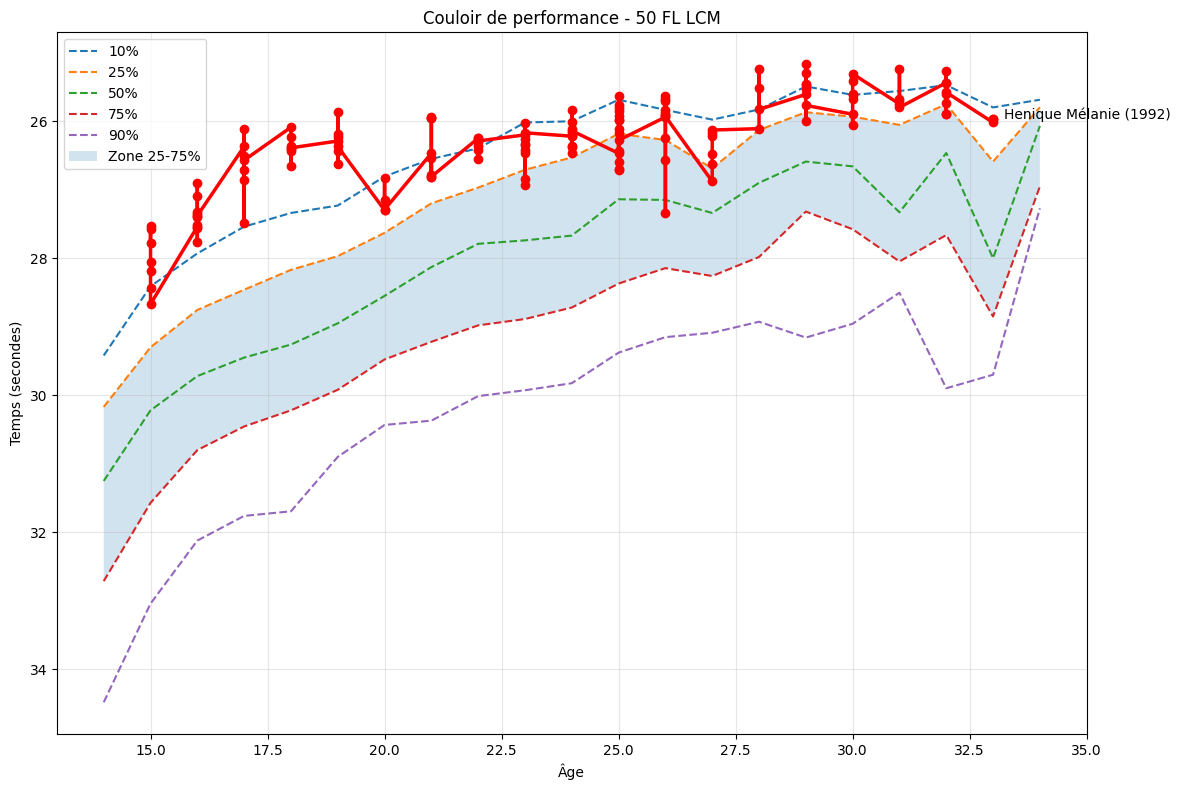

In [12]:
def build_long_swims(df, solo_only=True):
    data = df.copy()

    if solo_only:
        data = data[data["swimmer"].apply(
            lambda x: isinstance(x, list) and len(x) == 1
        )]

    data["swimmer_dict"] = data["swimmer"].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) == 1 else None
    )

    data["Name"] = data["swimmer_dict"].apply(lambda x: x.get("Name") if isinstance(x, dict) else None)
    data["Gender"] = data["swimmer_dict"].apply(lambda x: x.get("Gender") if isinstance(x, dict) else None)
    data["Year_of_birth"] = data["swimmer_dict"].apply(lambda x: x.get("Year_of_birth") if isinstance(x, dict) else None)
    data["Age_json"] = data["swimmer_dict"].apply(lambda x: x.get("Age") if isinstance(x, dict) else None)

    data["SwimYear"] = pd.to_datetime(data["SwimDate"], errors="coerce").dt.year

    data["Age_swim"] = data["Age_json"]

    mask = (
        data["Age_swim"].isna() &
        data["Year_of_birth"].notna() &
        data["SwimYear"].notna()
    )

    data.loc[mask, "Age_swim"] = (
        data.loc[mask, "SwimYear"] - data.loc[mask, "Year_of_birth"]
    )

    data["Age_swim"] = pd.to_numeric(data["Age_swim"], errors="coerce").astype("Int64")

    return data

def performance_corridor_plot_time(
    df,
    nom_event,
    nom_nageur,
    year_of_birth,
    age_min=14,
    age_max=35,
    solo_only=True,
    min_points=5,
    figsize=(12, 8),
):

    long_df = build_long_swims(df, solo_only=solo_only)

    long_df = long_df[
        (long_df["Event"] == nom_event) &
        (long_df["SwimTimeSeconds"].notna()) &
        (long_df["Name"].notna()) &
        (long_df["Gender"].notna()) &
        (long_df["Age_swim"].notna()) &
        (long_df["Year_of_birth"].notna())
    ].copy()

    if long_df.empty:
        print(f"Aucune donnée pour {nom_event}")
        return

    target_name = nom_nageur.strip().lower()

    swimmer_data = long_df[
        (long_df["Name"].str.strip().str.lower() == target_name) &
        (long_df["Year_of_birth"] == year_of_birth)
    ]

    if swimmer_data.empty:
        print(f"Nageur introuvable : {nom_nageur} ({year_of_birth})")
        print("Exemples :", long_df["Name"].drop_duplicates().head(10).tolist())
        return

    gender = swimmer_data["Gender"].mode().iloc[0]
    long_df = long_df[long_df["Gender"] == gender]

    swimmer_name = swimmer_data.iloc[0]["Name"]
    swimmer_yob = swimmer_data.iloc[0]["Year_of_birth"]

    percentiles = [10, 25, 50, 75, 90]

    grouped = long_df.groupby("Age_swim")["SwimTimeSeconds"].agg(list)

    grouped = grouped.apply(
        lambda x: x if len(x) >= min_points else np.nan
    ).dropna()

    df_percentiles = pd.DataFrame({
        f"p{p}": grouped.apply(lambda x: np.percentile(x, p))
        for p in percentiles
    })

    df_percentiles = df_percentiles.loc[
        (df_percentiles.index >= age_min) &
        (df_percentiles.index <= age_max)
    ]

    df_swimmer = long_df[
        (long_df["Name"] == swimmer_name) &
        (long_df["Year_of_birth"] == swimmer_yob)
    ].sort_values("Age_swim")

    fig, ax = plt.subplots(figsize=figsize)

    for p in percentiles:
        ax.plot(
            df_percentiles.index,
            df_percentiles[f"p{p}"],
            linestyle="--",
            label=f"{p}%"
        )

    ax.fill_between(
        df_percentiles.index,
        df_percentiles["p25"],
        df_percentiles["p75"],
        alpha=0.2,
        label="Zone 25-75%"
    )

    ax.plot(
        df_swimmer["Age_swim"],
        df_swimmer["SwimTimeSeconds"],
        color="red",
        linewidth=2.5,
        marker="o"
    )

    if not df_swimmer.empty:
        last = df_swimmer.iloc[-1]
        ax.scatter(last["Age_swim"], last["SwimTimeSeconds"], color="red")
        ax.annotate(
            f"{swimmer_name} ({swimmer_yob})",
            (last["Age_swim"], last["SwimTimeSeconds"]),
            xytext=(8, 0),
            textcoords="offset points"
        )

    ax.invert_yaxis()
    ax.set_xlabel("Âge")
    ax.set_ylabel("Temps (secondes)")
    ax.set_title(f"Couloir de performance - {nom_event}")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    return fig, ax

performance_corridor_plot_time(
    df,
    nom_event="50 FL LCM",
    nom_nageur="Henique Mélanie",
    year_of_birth=1992
)

plt.show()